# Big Data Fundamentals & Google Colab

### Installing Required Libraries

In [ ]:
!pip install pyspark dask seaborn matplotlib

***Description:***



* Installs the essential Python libraries for data processing, visualization, and big data analytics.
* `pyspark` is used for big data processing and machine learning pipelines.
* `dask` enables handling large datasets efficiently in parallel.
* `seaborn` and `matplotlib` are used for data visualization and plotting.
* Ensures that the working environment has all necessary packages before running the analysis.


###Installing Required Libraries



In [ ]:
!pip install requests beautifulsoup4 pandas pyspark scikit-learn xgboost imbalanced-learn

***Description:***


* Installs all required Python libraries for data collection, preprocessing, machine learning, and big data analytics.
* Ensures that the working environment is prepared before executing the analysis code.



###Importing Data Collection and Basic Processing Libraries

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np

***Description:***

* Imports `requests` and `BeautifulSoup` for web data collection and parsing.
* Imports `pandas` and `numpy` for data manipulation and numerical computations.

### Importing PySpark Libraries for Big Data Processing

In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler, MinMaxScaler, PCA
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

***Description:***


* Imports `SparkSession` to initialize Spark environment.
* Imports `VectorAssembler`, `StandardScaler`, `MinMaxScaler`, and `PCA` for feature preparation and dimensionality reduction.
* Imports `RandomForestClassifier` for model training and `MulticlassClassificationEvaluator`, `BinaryClassificationEvaluator` for performance evaluation.

### Importing Scikit-Learn Libraries for Machine Learning

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler as SkStandardScaler, MinMaxScaler as SkMinMaxScaler
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier as SkRandomForest
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

***Description:***

* Imports `train_test_split` and `GridSearchCV` for dataset splitting and hyperparameter tuning.
* Imports `StandardScaler` and `MinMaxScaler` for feature scaling.
* Imports `RFE` for feature selection.
* Imports `RandomForestClassifier` and `SVC` for model training.
* Imports metrics such as `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `roc_auc_score`, and `classification_report` for model evaluation.

### Handling Imbalanced Data and Advanced Models

In [ ]:
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

***Description:***

* Imports `SMOTE` to handle class imbalance by generating synthetic samples.
* Imports `XGBClassifier` for high-accuracy gradient boosting classification.

### Importing Visualization Libraries

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

***Description:***

* Imports `matplotlib.pyplot` and `seaborn` for data visualization.

  These libraries are used for data visualization. Matplotlib is used for basic plotting, while Seaborn provides enhanced and more informative statistical visualizations.


### Importing PySpark SQL Functions

In [ ]:
from pyspark.sql.functions import count, when, col

***Description:***

* Imports `count`, `when`, and `col` for data transformation and conditional operations in PySpark.

These PySpark SQL functions are used for data transformation and analysis. They help in counting records, applying conditional logic, and referencing DataFrame columns efficiently during data processing.

### Defining Dataset File Path

In [ ]:
file_path = "/content/drive/MyDrive/diabetes_dataset.csv"

***Description:***


* Defines the path of the dataset stored in Google Drive.
* The variable `file_path` is used to locate and load the CSV file into the program.

### Loading Dataset into Pandas DataFrame

In [ ]:
df_pd = pd.read_csv(file_path)
print("Pandas DataFrame Loaded. Shape:", df_pd.shape)

Pandas DataFrame Loaded. Shape: (100000, 31)


***Description:***

This code loads the dataset from the specified CSV file into a Pandas DataFrame named `df_pd.`


*  ` pd.read_csv()` reads the CSV file and converts it into a tabular format that can be easily manipulated in Python.

*  `df_pd.shape` displays the number of rows and columns in the dataset, which helps to quickly understand the dataset size.

*  Printing this message confirms that the data has been successfully loaded.
  



### Mounting Google Drive in Colab

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive mounted successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully!


***Description:***

This code mounts the Google Drive account to the Colab environment, allowing access to files stored in Drive.

* `drive.mount('/content/drive') `creates a connection between Colab and
your Google Drive.

* After mounting, datasets, models, and other files stored in Drive can be directly read or saved.

* Printing the success message confirms that the drive has been mounted correctly.

### Loading Dataset into Dask DataFrame

In [ ]:
import dask.dataframe as dd
df_dd = dd.read_csv(file_path)
print(" Dask DataFrame Loaded. Shape:", df_dd.shape)

 Dask DataFrame Loaded. Shape: (<dask_expr.expr.Scalar: expr=ArrowStringConversion(frame=FromMapProjectable(ad36e42)).size() // 31, dtype=int64>, 31)


***Description:***

This code loads the dataset into a Dask DataFrame named `df_dd.`

*` dask.dataframe` allows handling large datasets efficiently, even those that do not fit entirely in memory, by processing data in chunks.

* `dd.read_csv(file_path)` reads the CSV file into a Dask DataFrame similar to Pandas, but optimized for parallel computation.

* Printing the shape gives an overview of the dataset size and confirms that it has been successfully loaded.




### Displaying the First Rows of the Dataset

In [ ]:
print(" Head of Dataset:")
print(df_pd.head())

 Head of Dataset:
   age  gender ethnicity education_level  income_level employment_status  \
0   58    Male     Asian      Highschool  Lower-Middle          Employed   
1   48  Female     White      Highschool        Middle          Employed   
2   60    Male  Hispanic      Highschool        Middle        Unemployed   
3   74  Female     Black      Highschool           Low           Retired   
4   46    Male     White        Graduate        Middle           Retired   

  smoking_status  alcohol_consumption_per_week  \
0          Never                             0   
1         Former                             1   
2          Never                             1   
3          Never                             0   
4          Never                             1   

   physical_activity_minutes_per_week  diet_score  ...  hdl_cholesterol  \
0                                 215         5.7  ...               41   
1                                 143         6.7  ...               55   

***Description:***


* Displays the first few rows of the dataset using `head()`.
* Provides an initial view of the data, including column names and sample values.

### Displaying the Last Rows of the Dataset

In [ ]:
print("Tail of Dataset:")
print(df_pd.tail())

Tail of Dataset:
       age  gender ethnicity education_level  income_level employment_status  \
99995   46    Male     Other        Graduate  Upper-Middle        Unemployed   
99996   41  Female     White        Graduate        Middle          Employed   
99997   57  Female     Black       No formal  Upper-Middle          Employed   
99998   47  Female     Black      Highschool  Lower-Middle           Retired   
99999   52  Female     White    Postgraduate        Middle          Employed   

      smoking_status  alcohol_consumption_per_week  \
99995         Former                             1   
99996          Never                             3   
99997         Former                             4   
99998          Never                             3   
99999          Never                             1   

       physical_activity_minutes_per_week  diet_score  ...  hdl_cholesterol  \
99995                                 136         8.3  ...               45   
99996              

***Description:***


* Displays the last few rows of the dataset using `tail()`.
* Helps verify the integrity and completeness of the dataset.

### Checking Dataset Information

In [ ]:
print(" Dataset Info:")
print(df_pd.info())

 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_

***Description:***

* Displays a concise summary of the dataset using `info()`.
* Shows number of rows, columns, data types, and non-null counts.

### Checking Missing Values

In [ ]:
print(" Missing Values (per column):")
print(df_pd.isnull().sum())

 Missing Values (per column):
age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fa

***Description:***


* Checks for missing values in each column using `isnull().sum()`.
* Identifies incomplete data that may require cleaning or imputation.

### Handling Missing Values

In [ ]:
df_pd = df_pd.fillna(df_pd.mean(numeric_only=True))
print("Missing values handled (filled with column means).")

Missing values handled (filled with column means).


***Description:***


* Fills missing values in numeric columns with the mean of each column using `fillna()`.
* Ensures the dataset contains no null values for analysis or modeling.

### Selecting Specific Numeric Columns

In [ ]:
numeric_cols = df_pd.select_dtypes(include=[np.number]).columns.tolist()
cols_to_check = numeric_cols[9:20]

***Description:***


* Identifies all numeric columns and stores them in `numeric_cols`.
* Selects a subset of columns (indices 9 to 19) and stores them in `cols_to_check`.
* Focuses subsequent analysis or preprocessing on relevant numeric features.

### Removing Outliers Using IQR Method

In [ ]:
def remove_outliers_iqr(data, cols):
    for col in cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        data = data[(data[col] >= lower) & (data[col] <= upper)]
    return data


***Description:***

This function `remove_outliers_iqr` removes outliers from specified numeric columns using the Interquartile Range (IQR) method.

* For each column in `cols`, the first (Q1) and third quartiles (Q3) are calculated, and the IQR is determined as `Q3 - Q1`.
* Values outside the range `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]` are considered outliers and are removed from the dataset.
* The cleaned dataset, free from extreme outlier values, is returned for further analysis or modeling.


### Applying Outlier Removal Function

In [ ]:
df_clean = remove_outliers_iqr(df_pd, cols_to_check)

***Description:***

* Calls the `remove_outliers_iqr` function to remove outliers from the dataset.
* Targets the numeric columns specified in `cols_to_check`.
* Stores the resulting cleaned dataset in `df_clean`.
* Prepares the dataset for further analysis or modeling with extreme values removed.


### Visualizing Outliers Before Removal


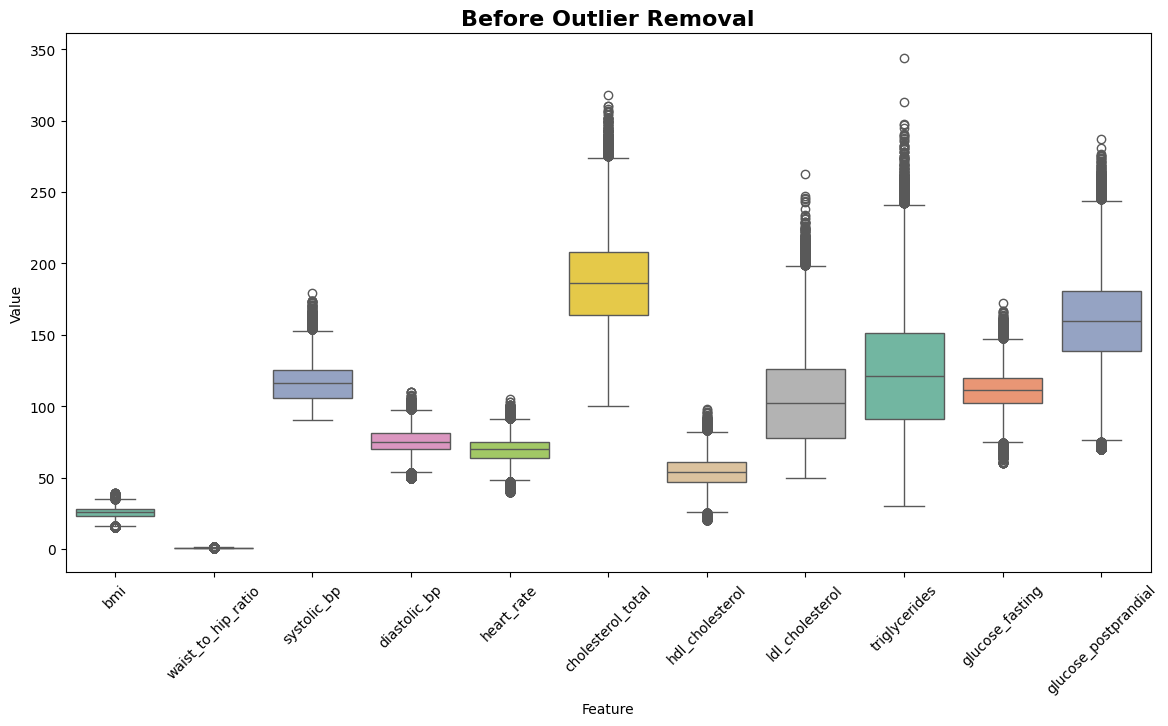

In [ ]:
df_melt_before = df_pd[cols_to_check].melt(var_name="Feature", value_name="Value")

plt.figure(figsize=(14,7))
sns.boxplot(x="Feature", y="Value", data=df_melt_before, hue="Feature",
            palette="Set2", fill=True, legend=False)
plt.title("Before Outlier Removal", fontsize=16, fontweight="bold")
plt.xticks(rotation=45)
plt.show()

***Description:***

* Creates a melted version of the selected numeric columns (`cols_to_check`) using the `melt()` function, resulting in `df_melt_before` with columns "Feature" and "Value".
* Plots a boxplot for each feature to visualize the distribution and identify potential outliers.
* Sets figure size to 14x7 inches for better readability.
* Uses Seaborn's `boxplot()` with a color palette "Set2" and disables legend.
* Adds a bold title "Before Outlier Removal" and rotates x-axis labels by 45 degrees for clarity.
* Displays the plot using `plt.show()`.

### Visualizing Outliers After Removal

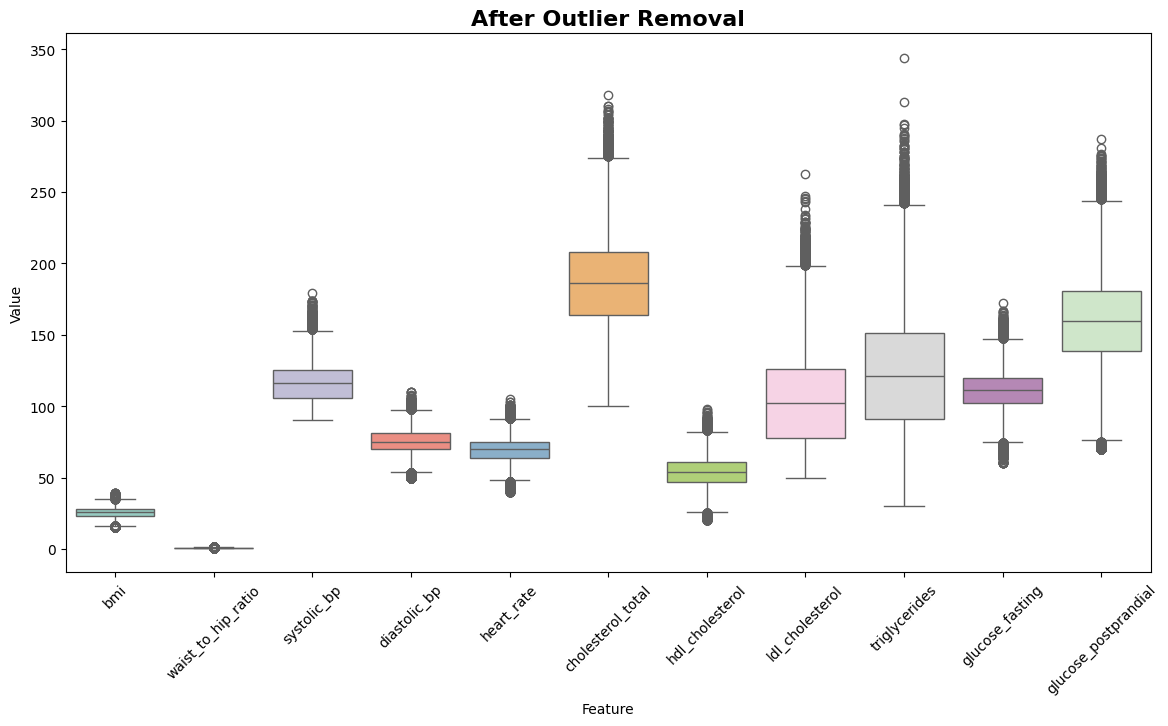

In [ ]:
df_melt_after = df_pd[cols_to_check].melt(var_name="Feature", value_name="Value")

plt.figure(figsize=(14,7))
sns.boxplot(x="Feature", y="Value", data=df_melt_after, hue="Feature",
            palette="Set3", fill=True, legend=False)
plt.title("After Outlier Removal", fontsize=16, fontweight="bold")
plt.xticks(rotation=45)
plt.show()

***Description:***

* Creates a melted version of the selected numeric columns (`cols_to_check`) using the `melt()` function, resulting in `df_melt_after` with columns "Feature" and "Value".
* Plots a boxplot for each feature to visualize the distribution after outlier removal.
* Sets figure size to 14x7 inches for better readability.
* Uses Seaborn's `boxplot()` with a color palette "Set3" and disables legend.
* Adds a bold title "After Outlier Removal" and rotates x-axis labels by 45 degrees for clarity.
* Displays the plot using `plt.show()`.

### Comparing Dataset Shape Before and After Outlier Removal

In [ ]:
print("Shape before:", df_pd.shape)
print("Shape after :", df_clean.shape)

Shape before: (100000, 31)
Shape after : (94389, 31)


***Description:***


* Prints the shape of the original dataset `df_pd` to show the number of rows and columns before removing outliers.
* Prints the shape of the cleaned dataset `df_clean` to show the number of rows and columns after removing outliers.
* Helps to understand how many records were removed during the outlier handling process.

# PySpark for Big Data Processing

### Setting Up PySpark and SparkSession

In [ ]:
!apt-get install -y openjdk-11-jdk-headless
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["PATH"] += ":/usr/lib/jvm/java-11-openjdk-amd64/bin"

from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("DiabetesSparkLab").getOrCreate()
print(" SparkSession created successfully!")


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  ca-certificates-java java-common libpcsclite1 openjdk-11-jre-headless
Suggested packages:
  default-jre pcscd openjdk-11-demo openjdk-11-source libnss-mdns
  fonts-dejavu-extra fonts-ipafont-gothic fonts-ipafont-mincho
  fonts-wqy-microhei | fonts-wqy-zenhei fonts-indic
The following NEW packages will be installed:
  ca-certificates-java java-common libpcsclite1 openjdk-11-jdk-headless
  openjdk-11-jre-headless
0 upgraded, 5 newly installed, 0 to remove and 41 not upgraded.
Need to get 116 MB of archives.
After this operation, 258 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 java-common all 0.72build2 [6,782 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libpcsclite1 amd64 1.9.5-3ubuntu1 [19.8 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 open

***Description:***

* Installs OpenJDK 11 required for running PySpark in the Colab environment using `apt-get`.
* Sets environment variables `JAVA_HOME` and updates `PATH` to point to the installed Java directory.
* Imports `SparkSession` from `pyspark.sql`.
* Creates a Spark session named "DiabetesSparkLab" using `SparkSession.builder`.
* Prints a confirmation message to indicate that the Spark session has been successfully initialized.
* Prepares the environment for big data processing and PySpark operations.


### Loading Dataset into PySpark DataFrame

In [ ]:
df_spark = spark.read.csv(file_path, header=True, inferSchema=True)

***Description:***

* Uses the Spark session `spark` to read the CSV file specified by `file_path`.
* Sets `header=True` to consider the first row as column names.
* Sets `inferSchema=True` to automatically detect the data types of each column.
* Stores the resulting PySpark DataFrame in `df_spark`.
* Prepares the dataset for big data processing and PySpark-based analysis.

### Inspecting Spark DataFrame Schema


In [ ]:
print("Spark DataFrame Loaded:")
df_spark.printSchema()

Spark DataFrame Loaded:
root
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- ethnicity: string (nullable = true)
 |-- education_level: string (nullable = true)
 |-- income_level: string (nullable = true)
 |-- employment_status: string (nullable = true)
 |-- smoking_status: string (nullable = true)
 |-- alcohol_consumption_per_week: integer (nullable = true)
 |-- physical_activity_minutes_per_week: integer (nullable = true)
 |-- diet_score: double (nullable = true)
 |-- sleep_hours_per_day: double (nullable = true)
 |-- screen_time_hours_per_day: double (nullable = true)
 |-- family_history_diabetes: integer (nullable = true)
 |-- hypertension_history: integer (nullable = true)
 |-- cardiovascular_history: integer (nullable = true)
 |-- bmi: double (nullable = true)
 |-- waist_to_hip_ratio: double (nullable = true)
 |-- systolic_bp: integer (nullable = true)
 |-- diastolic_bp: integer (nullable = true)
 |-- heart_rate: integer (nullable = true)
 |-- choles

***Description:***


* Prints a message indicating that the Spark DataFrame has been loaded successfully.
* Uses `df_spark.printSchema()` to display the structure of the DataFrame.
* Shows column names, data types, and nullability information.
* Helps verify that the dataset has been correctly loaded and the schema inferred properly for subsequent analysis.

### Displaying the First Rows of Spark DataFrame


In [ ]:
print("\nSpark DataFrame Head:")
df_spark.show(5)


Spark DataFrame Head:
+---+------+---------+---------------+------------+-----------------+--------------+----------------------------+----------------------------------+----------+-------------------+-------------------------+-----------------------+--------------------+----------------------+----+------------------+-----------+------------+----------+-----------------+---------------+---------------+-------------+---------------+--------------------+-------------+-----+-------------------+--------------+------------------+
|age|gender|ethnicity|education_level|income_level|employment_status|smoking_status|alcohol_consumption_per_week|physical_activity_minutes_per_week|diet_score|sleep_hours_per_day|screen_time_hours_per_day|family_history_diabetes|hypertension_history|cardiovascular_history| bmi|waist_to_hip_ratio|systolic_bp|diastolic_bp|heart_rate|cholesterol_total|hdl_cholesterol|ldl_cholesterol|triglycerides|glucose_fasting|glucose_postprandial|insulin_level|hba1c|diabetes_risk_

***Description:***

* Prints a message indicating that the first rows of the Spark DataFrame will be displayed.
* Uses `df_spark.show(5)` to display the first 5 rows of the DataFrame.
* Provides a quick preview of the dataset, including sample values for each column.
* Helps verify that the data has been correctly loaded into the Spark DataFrame.

### Checking Missing Values in Spark DataFrame

In [ ]:
print("Missing Values (Spark):")
df_spark.select([count(when(col(c).isNull(), c)).alias(c) for c in df_spark.columns]).show()

Missing Values (Spark):
+---+------+---------+---------------+------------+-----------------+--------------+----------------------------+----------------------------------+----------+-------------------+-------------------------+-----------------------+--------------------+----------------------+---+------------------+-----------+------------+----------+-----------------+---------------+---------------+-------------+---------------+--------------------+-------------+-----+-------------------+--------------+------------------+
|age|gender|ethnicity|education_level|income_level|employment_status|smoking_status|alcohol_consumption_per_week|physical_activity_minutes_per_week|diet_score|sleep_hours_per_day|screen_time_hours_per_day|family_history_diabetes|hypertension_history|cardiovascular_history|bmi|waist_to_hip_ratio|systolic_bp|diastolic_bp|heart_rate|cholesterol_total|hdl_cholesterol|ldl_cholesterol|triglycerides|glucose_fasting|glucose_postprandial|insulin_level|hba1c|diabetes_risk_s

***Description:***


* Prints a message indicating that missing values in the Spark DataFrame will be displayed.
* Uses a list comprehension with `count` and `when` to count null values for each column.
* `alias(c)` ensures that the output columns retain their original names.
* Displays the count of missing values per column using `.show()`.
* Helps identify incomplete data that may require cleaning or imputation before analysis.

### Performing RDD Transformations

In [ ]:
print(" RDD Transformations ")
rdd_glucose = df_spark.select("glucose_fasting").rdd.flatMap(lambda x: x)

 RDD Transformations 


***Description:***

* Prints a message indicating that RDD transformations will be performed.
* Selects the column `glucose_fasting` from the Spark DataFrame `df_spark`.
* Converts the selected column to an RDD using `.rdd`.
* Applies `flatMap(lambda x: x)` to flatten the RDD, resulting in a one-dimensional collection of glucose values.
* Prepares the data for further RDD-based transformations or analyses.

### Creating RDD from Spark DataFrame

In [ ]:
rdd = df_spark.rdd
print(" RDD Created Successfully! First 3 rows:")
print(rdd.take(3))

 RDD Created Successfully! First 3 rows:
[Row(age=58, gender='Male', ethnicity='Asian', education_level='Highschool', income_level='Lower-Middle', employment_status='Employed', smoking_status='Never', alcohol_consumption_per_week=0, physical_activity_minutes_per_week=215, diet_score=5.7, sleep_hours_per_day=7.9, screen_time_hours_per_day=7.9, family_history_diabetes=0, hypertension_history=0, cardiovascular_history=0, bmi=30.5, waist_to_hip_ratio=0.89, systolic_bp=134, diastolic_bp=78, heart_rate=68, cholesterol_total=239, hdl_cholesterol=41, ldl_cholesterol=160, triglycerides=145, glucose_fasting=136, glucose_postprandial=236, insulin_level=6.36, hba1c=8.18, diabetes_risk_score=29.6, diabetes_stage='Type 2', diagnosed_diabetes=1), Row(age=48, gender='Female', ethnicity='White', education_level='Highschool', income_level='Middle', employment_status='Employed', smoking_status='Former', alcohol_consumption_per_week=1, physical_activity_minutes_per_week=143, diet_score=6.7, sleep_hours_pe

***Description:***


* Converts the entire Spark DataFrame `df_spark` into an RDD using `.rdd`.
* Prints a message indicating that the RDD has been successfully created.
* Uses `rdd.take(3)` to display the first 3 rows of the RDD.
* Provides a quick preview of the RDD contents for verification.
* Prepares the data for RDD-based transformations or actions.

### Applying Map Transformation on RDD

In [ ]:
rdd_map = rdd.map(lambda row: (row.age, row.glucose_fasting * 2))
print("\n MAP → Double fasting glucose values:")
print(rdd_map.take(5))


 MAP → Double fasting glucose values:
[(58, 272), (48, 186), (60, 236), (74, 278), (46, 274)]


***Description:***

* Uses the `map()` transformation on the RDD to create a new RDD `rdd_map`.
* Each element in the new RDD is a tuple containing `age` and `glucose_fasting` multiplied by 2.
* Prints a message indicating that the RDD has been transformed using `map`.
* Uses `rdd_map.take(5)` to display the first 5 transformed records.
* Demonstrates how `map` can be used to apply element-wise operations on RDDs.

### Applying Filter Transformation on RDD

In [ ]:
rdd_filter = rdd.filter(lambda row: row.glucose_fasting > 120)
print("\n FILTER → Patients with fasting glucose > 120:")
print(rdd_filter.take(5))


 FILTER → Patients with fasting glucose > 120:
[Row(age=58, gender='Male', ethnicity='Asian', education_level='Highschool', income_level='Lower-Middle', employment_status='Employed', smoking_status='Never', alcohol_consumption_per_week=0, physical_activity_minutes_per_week=215, diet_score=5.7, sleep_hours_per_day=7.9, screen_time_hours_per_day=7.9, family_history_diabetes=0, hypertension_history=0, cardiovascular_history=0, bmi=30.5, waist_to_hip_ratio=0.89, systolic_bp=134, diastolic_bp=78, heart_rate=68, cholesterol_total=239, hdl_cholesterol=41, ldl_cholesterol=160, triglycerides=145, glucose_fasting=136, glucose_postprandial=236, insulin_level=6.36, hba1c=8.18, diabetes_risk_score=29.6, diabetes_stage='Type 2', diagnosed_diabetes=1), Row(age=74, gender='Female', ethnicity='Black', education_level='Highschool', income_level='Low', employment_status='Retired', smoking_status='Never', alcohol_consumption_per_week=0, physical_activity_minutes_per_week=49, diet_score=3.4, sleep_hours_p

***Description:***

* Uses the `filter()` transformation on the RDD to create a new RDD `rdd_filter`.
* Retains only those rows where `glucose_fasting` is greater than 120.
* Prints a message indicating that the RDD has been filtered based on the glucose threshold.
* Uses `rdd_filter.take(5)` to display the first 5 records meeting the condition.
* Demonstrates how `filter` can be used to select specific elements from an RDD based on a condition.

### Applying FlatMap Transformation on RDD

In [ ]:
rdd_flat = rdd.flatMap(lambda row: row.diabetes_stage.split(" "))
print("\n FLATMAP → Split words from diabetes_stage:")
print(rdd_flat.take(10))


 FLATMAP → Split words from diabetes_stage:
['Type', '2', 'No', 'Diabetes', 'Type', '2', 'Type', '2', 'Type', '2']


***Description:***

* Uses the `flatMap()` transformation on the RDD to create a new RDD `rdd_flat`.
* Splits the string values in the column `diabetes_stage` by spaces, flattening the result into individual words.
* Prints a message indicating that the RDD has been transformed using `flatMap`.
* Uses `rdd_flat.take(10)` to display the first 10 elements of the flattened RDD.
* Demonstrates how `flatMap` can be used to transform and flatten nested or list-like data in an RDD.

### Extracting Distinct Values from RDD

In [ ]:
rdd_distinct = rdd.map(lambda row: row.education_level).distinct()
print("\n DISTINCT → Unique education levels:")
print(rdd_distinct.collect())



 DISTINCT → Unique education levels:
['Highschool', 'Graduate', 'Postgraduate', 'No formal']


***Description:***

* Uses the `map()` transformation on the RDD to select the `education_level` column.
* Applies the `distinct()` transformation to obtain unique education levels.
* Prints a message indicating that distinct values are being extracted.
* Uses `rdd_distinct.collect()` to display all unique education levels in the dataset.
* Demonstrates how `distinct` can be used to identify unique elements in an RDD.

### Performing Union, Intersection, and Subtract on RDDs

In [ ]:
rdd1 = rdd.map(lambda row: row.diabetes_stage)
rdd2 = rdd.map(lambda row: str(row.diagnosed_diabetes))

print("\n UNION (stage + diagnosed):")
print(rdd1.union(rdd2).take(10))

print("\nINTERSECTION (common values between stage & diagnosis):")
print(rdd1.intersection(rdd2).take(10))

print("\n SUBTRACT (stage values not in diagnosis):")
print(rdd1.subtract(rdd2).take(10))


 UNION (stage + diagnosed):
['Type 2', 'No Diabetes', 'Type 2', 'Type 2', 'Type 2', 'Pre-Diabetes', 'Pre-Diabetes', 'Type 2', 'Type 2', 'No Diabetes']

INTERSECTION (common values between stage & diagnosis):
[]

 SUBTRACT (stage values not in diagnosis):
['Gestational', 'Gestational', 'Gestational', 'Gestational', 'Gestational', 'Gestational', 'Gestational', 'Gestational', 'Gestational', 'Gestational']


***Description:***


* Creates two RDDs: `rdd1` containing `diabetes_stage` and `rdd2` containing `diagnosed_diabetes` converted to strings.
* **Union:** Combines all elements from `rdd1` and `rdd2` using `union()` and displays the first 10 records.
* **Intersection:** Finds common elements between `rdd1` and `rdd2` using `intersection()` and displays the first 10 common values.
* **Subtract:** Identifies elements present in `rdd1` but not in `rdd2` using `subtract()` and displays the first 10 such values.
* Demonstrates basic set operations on RDDs for comparative analysis between two datasets or columns.


### Performing Actions on RDD

In [ ]:
print("\n COLLECT → Age and BMI:")
print(rdd.map(lambda row: (row.age, row.bmi)).take(5))

print("\n COUNT → Total records:")
print(rdd.count())

print("\n TAKE → First 5 rows:")
print(rdd.take(5))

glucose_sum = rdd.map(lambda row: row.glucose_fasting).reduce(lambda x, y: x + y)
print("\n REDUCE → Total glucose fasting sum:")
print(glucose_sum)


 COLLECT → Age and BMI:
[(58, 30.5), (48, 23.1), (60, 22.2), (74, 26.8), (46, 21.2)]

 COUNT → Total records:
100000

 TAKE → First 5 rows:
[Row(age=58, gender='Male', ethnicity='Asian', education_level='Highschool', income_level='Lower-Middle', employment_status='Employed', smoking_status='Never', alcohol_consumption_per_week=0, physical_activity_minutes_per_week=215, diet_score=5.7, sleep_hours_per_day=7.9, screen_time_hours_per_day=7.9, family_history_diabetes=0, hypertension_history=0, cardiovascular_history=0, bmi=30.5, waist_to_hip_ratio=0.89, systolic_bp=134, diastolic_bp=78, heart_rate=68, cholesterol_total=239, hdl_cholesterol=41, ldl_cholesterol=160, triglycerides=145, glucose_fasting=136, glucose_postprandial=236, insulin_level=6.36, hba1c=8.18, diabetes_risk_score=29.6, diabetes_stage='Type 2', diagnosed_diabetes=1), Row(age=48, gender='Female', ethnicity='White', education_level='Highschool', income_level='Middle', employment_status='Employed', smoking_status='Former', al

***Description:***


* **Collect & Take:** Uses `rdd.map(lambda row: (row.age, row.bmi)).take(5)` to display the first 5 tuples of Age and BMI.
* **Count:** Uses `rdd.count()` to get the total number of records in the RDD.
* **Take:** Uses `rdd.take(5)` to preview the first 5 rows of the RDD.
* **Reduce:** Uses `rdd.map(lambda row: row.glucose_fasting).reduce(lambda x, y: x + y)` to compute the total sum of `glucose_fasting`.
* Demonstrates common RDD actions for extracting, aggregating, and summarizing data.

### Reducing RDD by Key

In [ ]:
rdd_kv = rdd.map(lambda row: (row.diabetes_stage, row.glucose_fasting))
rdd_reduced = rdd_kv.reduceByKey(lambda x, y: x + y)
print("\n REDUCE BY KEY → Total glucose fasting per stage:")
print(rdd_reduced.collect())


 REDUCE BY KEY → Total glucose fasting per stage:
[('Type 2', 6981564), ('No Diabetes', 718738), ('Pre-Diabetes', 3368213), ('Gestational', 30182), ('Type 1', 13015)]


***Description:***

* Creates a key-value RDD `rdd_kv` where the key is `diabetes_stage` and the value is `glucose_fasting`.
* Uses `reduceByKey(lambda x, y: x + y)` to sum `glucose_fasting` values for each diabetes stage.
* Stores the result in `rdd_reduced`.
* Prints the aggregated total glucose fasting per diabetes stage using `rdd_reduced.collect()`.
* Demonstrates how `reduceByKey` can perform grouped aggregation on key-value RDDs.

### Grouping RDD by Key

In [ ]:
rdd_group = rdd_kv.groupByKey().mapValues(list)
print("\n GROUP BY KEY → Glucose fasting grouped by stage:")
print(rdd_group.take(3))


 GROUP BY KEY → Glucose fasting grouped by stage:
[('Type 2', [136, 118, 139, 137, 110, 116, 124, 117, 123, 105, 100, 101, 132, 117, 113, 107, 100, 107, 129, 108, 118, 119, 124, 137, 120, 120, 133, 124, 101, 114, 101, 120, 119, 106, 124, 154, 130, 96, 121, 116, 105, 143, 119, 130, 100, 120, 98, 118, 127, 126, 101, 109, 125, 120, 111, 127, 121, 104, 113, 113, 112, 122, 123, 111, 112, 133, 113, 111, 113, 97, 118, 125, 122, 136, 99, 134, 115, 108, 108, 113, 99, 128, 114, 117, 111, 117, 119, 115, 119, 117, 104, 122, 122, 118, 139, 115, 115, 116, 120, 118, 113, 131, 120, 107, 114, 113, 118, 125, 118, 107, 125, 114, 133, 128, 109, 111, 108, 124, 100, 138, 132, 124, 111, 128, 112, 112, 92, 121, 115, 105, 131, 127, 115, 112, 98, 115, 145, 100, 115, 102, 100, 131, 108, 113, 91, 103, 95, 136, 124, 123, 130, 131, 129, 114, 119, 112, 121, 140, 113, 105, 123, 127, 116, 118, 119, 94, 101, 113, 135, 105, 103, 126, 117, 106, 128, 116, 126, 123, 105, 105, 136, 119, 106, 134, 115, 120, 112, 104, 107, 1

***Description:***


* Uses the key-value RDD `rdd_kv` where the key is `diabetes_stage` and the value is `glucose_fasting`.
* Applies `groupByKey()` to group all glucose fasting values by their corresponding diabetes stage.
* Converts grouped values into a list using `mapValues(list)` and stores the result in `rdd_group`.
* Prints the first 3 grouped records using `rdd_group.take(3)`.
* Demonstrates how `groupByKey` can organize data into collections for each unique key.


### Joining RDDs by Key

In [ ]:
rdd_glucose = rdd.map(lambda row: (row.diabetes_stage, row.glucose_fasting))
rdd_hba1c = rdd.map(lambda row: (row.diabetes_stage, row.hba1c))
rdd_joined = rdd_glucose.join(rdd_hba1c)
print("\n JOIN → Glucose and HbA1c joined by diabetes_stage:")
print(rdd_joined.take(5))


 JOIN → Glucose and HbA1c joined by diabetes_stage:
[('Gestational', (107, 6.52)), ('Gestational', (107, 7.28)), ('Gestational', (107, 5.25)), ('Gestational', (107, 6.27)), ('Gestational', (107, 5.93))]


***Description:***

* Creates two key-value RDDs: `rdd_glucose` (key: `diabetes_stage`, value: `glucose_fasting`) and `rdd_hba1c` (key: `diabetes_stage`, value: `hba1c`).
* Uses `join()` to combine both RDDs based on the common key `diabetes_stage`.
* Stores the resulting joined RDD in `rdd_joined`.
* Prints the first 5 records of the joined RDD using `rdd_joined.take(5)`.
* Demonstrates how to combine multiple RDDs by key for comparative or relational analysis.

### Filtering Spark DataFrame Using Conditions

In [ ]:
print(" DATAFRAME & SQL QUERIES")

filtered_df = df_spark.filter((df_spark.age > 40) & (df_spark.glucose_fasting > 120)).select("age", "bmi", "glucose_fasting")
print("\n FILTERED DATAFRAME → Age > 40 & Glucose > 120:")
filtered_df.show(5)

 DATAFRAME & SQL QUERIES

 FILTERED DATAFRAME → Age > 40 & Glucose > 120:
+---+----+---------------+
|age| bmi|glucose_fasting|
+---+----+---------------+
| 58|30.5|            136|
| 74|26.8|            139|
| 46|21.2|            137|
| 43|24.8|            124|
| 54|31.2|            123|
+---+----+---------------+
only showing top 5 rows



***Description:***


* Prints a message indicating that DataFrame filtering and SQL-style queries will be demonstrated.
* Filters `df_spark` to include only rows where `age > 40` and `glucose_fasting > 120`.
* Selects only the columns `age`, `bmi`, and `glucose_fasting` from the filtered DataFrame.
* Stores the resulting filtered DataFrame in `filtered_df`.
* Displays the first 5 rows of `filtered_df` using `.show(5)`.
* Demonstrates how to apply conditional filtering on a Spark DataFrame for analysis.


### Querying Spark DataFrame Using SQL

In [ ]:
df_spark.createOrReplaceTempView("diabetes")
sql_result = spark.sql("""
SELECT gender, age, glucose_fasting, diabetes_stage
FROM diabetes
WHERE glucose_fasting > 120 AND diagnosed_diabetes = 1
""")
print("\n SPARK SQL → Diabetic patients with glucose_fasting > 120:")
sql_result.show(5)


 SPARK SQL → Diabetic patients with glucose_fasting > 120:
+------+---+---------------+--------------+
|gender|age|glucose_fasting|diabetes_stage|
+------+---+---------------+--------------+
|  Male| 58|            136|        Type 2|
|Female| 74|            139|        Type 2|
|  Male| 46|            137|        Type 2|
|Female| 43|            124|        Type 2|
|Female| 54|            123|        Type 2|
+------+---+---------------+--------------+
only showing top 5 rows



***Description:***


* Creates a temporary SQL view named `diabetes` from the Spark DataFrame `df_spark` using `createOrReplaceTempView()`.
* Executes a Spark SQL query to select `gender`, `age`, `glucose_fasting`, and `diabetes_stage` for patients with `glucose_fasting > 120` and `diagnosed_diabetes = 1`.
* Stores the query result in `sql_result`.
* Prints a message indicating that the SQL query results will be displayed.
* Uses `.show(5)` to display the first 5 rows of the query result.
* Demonstrates how to perform SQL-style queries directly on Spark DataFrames for analysis.

### Grouping Spark DataFrame to Calculate Average

In [ ]:
print("\n GROUP BY diabetes_stage → Average glucose_fasting:")
df_spark.groupBy("diabetes_stage").avg("glucose_fasting").show()


 GROUP BY diabetes_stage → Average glucose_fasting:
+--------------+--------------------+
|diabetes_stage|avg(glucose_fasting)|
+--------------+--------------------+
|   No Diabetes|   90.05613331662698|
|  Pre-Diabetes|  105.76897472130632|
|   Gestational|  108.56834532374101|
|        Type 1|  106.68032786885246|
|        Type 2|  116.79934419647338|
+--------------+--------------------+



***Description:***

 Prints a message indicating that the DataFrame will be grouped to calculate averages.
* Groups the Spark DataFrame `df_spark` by `diabetes_stage`.
* Calculates the average of `glucose_fasting` for each diabetes stage using `.avg()`.
* Displays the grouped results with `.show()`.
* Demonstrates how to perform aggregation operations on Spark DataFrames to summarize data.

### Joining Spark DataFrames

In [ ]:
df2 = df_spark.select("age", "bmi")
joined_df = df_spark.join(df2, on="age", how="inner")
print("\n DATAFRAME JOIN → On 'age':")
joined_df.show(5)


 DATAFRAME JOIN → On 'age':
+---+------+---------+---------------+------------+-----------------+--------------+----------------------------+----------------------------------+----------+-------------------+-------------------------+-----------------------+--------------------+----------------------+----+------------------+-----------+------------+----------+-----------------+---------------+---------------+-------------+---------------+--------------------+-------------+-----+-------------------+--------------+------------------+----+
|age|gender|ethnicity|education_level|income_level|employment_status|smoking_status|alcohol_consumption_per_week|physical_activity_minutes_per_week|diet_score|sleep_hours_per_day|screen_time_hours_per_day|family_history_diabetes|hypertension_history|cardiovascular_history| bmi|waist_to_hip_ratio|systolic_bp|diastolic_bp|heart_rate|cholesterol_total|hdl_cholesterol|ldl_cholesterol|triglycerides|glucose_fasting|glucose_postprandial|insulin_level|hba1c|dia

***Description:***


* Selects columns `age` and `bmi` from `df_spark` into a new DataFrame `df2`.
* Performs an inner join between `df_spark` and `df2` on the column `age`.
* Stores the resulting joined DataFrame in `joined_df`.
* Prints a message indicating that the DataFrame join has been performed.
* Displays the first 5 rows of the joined DataFrame using `.show(5)`.
* Demonstrates how to combine two Spark DataFrames based on a common column.

# Caching & Persistence

Caching, Persistence, and Column Transformation

In [ ]:
import time
from pyspark.storagelevel import StorageLevel
from pyspark.sql import functions as F

print("\nCaching & Persistence ")
df = df_spark.select("age", "bmi", "glucose_fasting", "diabetes_stage")
df_transformed = df.withColumn("bmi_squared", F.col("bmi") ** 2)


Caching & Persistence 


***Description:***


* Imports necessary libraries for caching (`StorageLevel`) and SQL functions (`functions as F`) in PySpark.
* Prints a message indicating that caching and persistence operations are being demonstrated.
* Selects relevant columns `age`, `bmi`, `glucose_fasting`, and `diabetes_stage` from `df_spark` into a new DataFrame `df`.
* Creates a new column `bmi_squared` by squaring the `bmi` values using `withColumn()` and `F.col()`.
* Stores the transformed DataFrame in `df_transformed`.
* Demonstrates how to perform column transformations and prepare data for further analysis or caching.

### Measuring Execution Time Without Caching

In [ ]:
start = time.time()
res_no_cache = df_transformed.filter(F.col("glucose_fasting") > 120)\
                             .groupBy("diabetes_stage")\
                             .agg(F.avg("bmi_squared").alias("avg_bmi_sq")).collect()
time_no_cache = time.time() - start

***Description:***



* Records the start time using `time.time()`.
* Filters `df_transformed` to include rows where `glucose_fasting > 120`.
* Groups the filtered DataFrame by `diabetes_stage`.
* Calculates the average of `bmi_squared` for each group using `.agg()` and aliases it as `avg_bmi_sq`.
* Collects the results into `res_no_cache`.
* Calculates the total execution time without caching and stores it in `time_no_cache`.
* Demonstrates how to measure performance of Spark operations and the impact of caching on execution speed.


### Caching DataFrame and Measuring Execution Time

In [ ]:
df_cached = df_transformed.cache()
df_cached.count()

start = time.time()
res_cache = df_cached.filter(F.col("glucose_fasting") > 120)\
                     .groupBy("diabetes_stage")\
                     .agg(F.avg("bmi_squared").alias("avg_bmi_sq")).collect()
time_cache = time.time() - start

df_cached.unpersist()


DataFrame[age: int, bmi: double, glucose_fasting: int, diabetes_stage: string, bmi_squared: double]

***Description:***



* Caches the transformed DataFrame `df_transformed` using `.cache()` and stores it in `df_cached`.
* Triggers the caching by calling `.count()` to force materialization.
* Records the start time using `time.time()`.
* Filters `df_cached` for rows where `glucose_fasting > 120`.
* Groups the filtered DataFrame by `diabetes_stage` and calculates the average of `bmi_squared`, aliasing it as `avg_bmi_sq`.
* Collects the results into `res_cache`.
* Calculates the total execution time with caching and stores it in `time_cache`.
* Releases the cached DataFrame from memory using `.unpersist()`.
* Demonstrates the performance improvement of Spark operations when caching is applied.


### Comparing Execution Time and Speedup with Caching

In [ ]:
print(f"\nTime without cache: {time_no_cache:.4f} sec")
print(f"Time with cache   : {time_cache:.4f} sec")
print(f"Speedup: {((time_no_cache - time_cache)/time_no_cache)*100:.2f}%")
print("Result Sample:", res_cache[:3])


Time without cache: 0.9962 sec
Time with cache   : 0.6104 sec
Speedup: 38.73%
Result Sample: [Row(diabetes_stage='Pre-Diabetes', avg_bmi_sq=689.7427914951992), Row(diabetes_stage='Gestational', avg_bmi_sq=701.4502), Row(diabetes_stage='Type 1', avg_bmi_sq=613.813125)]


***Description:***



* Prints the execution time without caching (`time_no_cache`) formatted to 4 decimal places.
* Prints the execution time with caching (`time_cache`) formatted to 4 decimal places.
* Calculates and prints the percentage speedup achieved using caching.
* Displays a sample of the first 3 results from `res_cache`.
* Demonstrates the performance benefit of caching in Spark and provides a quick check of the computation results.


# Partitioning & Parallelism

### Exploring Partitioning and Parallelism in RDDs

In [ ]:
print("\n Partitioning & Parallelism ")

rdd = df_spark.rdd
print("Default Partitions:", rdd.getNumPartitions())


 Partitioning & Parallelism 
Default Partitions: 2


***Description:***



* Prints a message indicating that RDD partitioning and parallelism will be demonstrated.
* Converts the Spark DataFrame `df_spark` into an RDD using `.rdd`.
* Uses `rdd.getNumPartitions()` to display the default number of partitions in the RDD.
* Helps understand how Spark distributes data across partitions for parallel processing.


### Measuring Execution Time with Different RDD Partitions

In [ ]:
def time_groupby(p):
    r = df_spark.repartition(p)
    start = time.time()
    r.groupBy("diabetes_stage").count().collect()
    t = time.time() - start
    print(f"Partitions: {p} | Time: {t:.3f} sec")

for parts in [2, 4, 8, 16]:
    time_groupby(parts)

Partitions: 2 | Time: 2.340 sec
Partitions: 4 | Time: 1.639 sec
Partitions: 8 | Time: 1.391 sec
Partitions: 16 | Time: 1.494 sec


***Description:***



* Defines a function `time_groupby(p)` to measure the effect of the number of partitions on execution time.
* Repartitions the Spark DataFrame `df_spark` into `p` partitions using `.repartition(p)`.
* Records the start time, performs a `groupBy("diabetes_stage").count()`, and collects the results.
* Calculates the elapsed time and prints the number of partitions along with execution time.
* Calls the function for different partition values `[2, 4, 8, 16]`.
* Demonstrates how partitioning affects parallelism and performance in Spark operations.


### Processing RDD Using mapPartitions

In [ ]:
def process_partition(iterator):
    for row in iterator:
        yield (row.diabetes_stage, float(row.glucose_fasting or 0) + 5)

rdd = df_spark.rdd.repartition(4)
processed = rdd.mapPartitions(process_partition)
print("\nSample processed records:", processed.take(10))


Sample processed records: [('Pre-Diabetes', 105.0), ('Pre-Diabetes', 115.0), ('Type 2', 113.0), ('Type 2', 123.0), ('Type 2', 124.0), ('Type 2', 129.0), ('Pre-Diabetes', 114.0), ('Type 2', 142.0), ('Type 2', 125.0), ('Pre-Diabetes', 117.0)]


***Description:***



* Defines a function `process_partition(iterator)` to process each partition of the RDD.
* Iterates over rows in the partition and yields a tuple with `diabetes_stage` and `glucose_fasting + 5` (handling nulls by using 0).
* Repartitions the Spark DataFrame RDD into 4 partitions using `.repartition(4)`.
* Applies `mapPartitions(process_partition)` to perform partition-wise transformation and stores the result in `processed`.
* Prints a sample of the first 10 processed records using `processed.take(10)`.
* Demonstrates how `mapPartitions` allows efficient processing of RDDs at the partition level.


# Broadcast Variables & Accumulators

### Setting Up Broadcast Variables and Accumulators

In [ ]:
print("\nBroadcast Variables & Accumulators ")

from pyspark import SparkContext
sc = SparkContext.getOrCreate()


Broadcast Variables & Accumulators 


***description:***



* Prints a message indicating that broadcast variables and accumulators will be demonstrated.
* Imports `SparkContext` from `pyspark`.
* Retrieves the active SparkContext or creates a new one using `SparkContext.getOrCreate()`.
* Prepares the Spark environment for using broadcast variables and accumulators for efficient distributed computations.


### Using Broadcast Variables in Spark

In [ ]:
allowed_levels = ["Primary", "Secondary", "Graduate", "Postgraduate"]
b_allowed = sc.broadcast(set(allowed_levels))

rdd = df_spark.rdd
filtered = rdd.filter(lambda row: row.education_level in b_allowed.value)
print("Filtered count (broadcast variable):", filtered.count())


Filtered count (broadcast variable): 50009


***Description:***



* Defines a list `allowed_levels` containing education levels to filter.
* Broadcasts the set of allowed levels to all Spark worker nodes using `sc.broadcast()`, stored in `b_allowed`.
* Converts the Spark DataFrame `df_spark` into an RDD.
* Filters the RDD to include only rows where `education_level` is in the broadcasted set using `b_allowed.value`.
* Prints the count of filtered records using `.count()`.
* Demonstrates how broadcast variables can efficiently share read-only data across all worker nodes in Spark.


### Using Accumulators in Spark

In [ ]:
acc_null = sc.accumulator(0)

def check_null(row):
    if row.glucose_fasting is None:
        acc_null.add(1)
    return row

_ = rdd.map(check_null).count()
print("Null glucose_fasting count (accumulator):", acc_null.value)

Null glucose_fasting count (accumulator): 0


***Description:***



* Creates an accumulator `acc_null` initialized to 0 for counting null values.
* Defines a function `check_null(row)` that increments the accumulator if `glucose_fasting` is `None`.
* Applies `rdd.map(check_null)` to process each row and triggers the computation with `.count()`.
* Prints the total count of null `glucose_fasting` values using `acc_null.value`.
* Demonstrates how accumulators can be used to perform distributed counting and aggregation in Spark.


# Performance Tuning

### Preparing DataFrame for Performance Tuning

In [ ]:
print("\nPerformance Tuning ")
df = df_spark.select("age", "bmi", "glucose_fasting", "diabetes_stage")


Performance Tuning 


***Description:***



* Prints a message indicating that performance tuning operations will be demonstrated.
* Selects relevant columns `age`, `bmi`, `glucose_fasting`, and `diabetes_stage` from `df_spark`.
* Stores the resulting DataFrame in `df`.
* Prepares a focused subset of the data for performance optimization and tuning experiments in Spark.


### Defining a Function to Measure Spark Job Performance with Persistence Levels

In [ ]:
def run_job(level=None):
    if level:
        df_p = df.persist(level)
        df_p.count()
    else:
        df_p = df
    start = time.time()
    df_p.groupBy("diabetes_stage").agg(F.avg("glucose_fasting")).collect()
    duration = time.time() - start
    if level:
        df_p.unpersist()
    return duration

***Description:***



* Defines a function `run_job(level=None)` to measure execution time with optional persistence.
* If a persistence `level` is provided, the DataFrame `df` is persisted using `.persist(level)` and materialized with `.count()`.
* Performs a `groupBy("diabetes_stage")` and calculates the average `glucose_fasting`, collecting the results.
* Measures and stores the duration of the job using `time.time()`.
* If persistence was applied, unpersists the DataFrame using `.unpersist()` to free memory.
* Returns the execution time.
* Demonstrates how different persistence levels can impact performance in Spark jobs.


### Comparing Execution Time Across Different Persistence Levels

In [ ]:
for lvl in [None, StorageLevel.MEMORY_ONLY, StorageLevel.MEMORY_AND_DISK]:
    dur = run_job(lvl)
    print(f"Storage Level: {lvl} | Time: {dur:.3f} sec")

Storage Level: None | Time: 1.088 sec
Storage Level: Memory Serialized 1x Replicated | Time: 0.613 sec
Storage Level: Disk Memory Serialized 1x Replicated | Time: 0.542 sec


***Description:***



* Iterates over different storage levels: `None` (no persistence), `MEMORY_ONLY`, and `MEMORY_AND_DISK`.
* Calls the `run_job(lvl)` function for each storage level to measure execution time.
* Prints the storage level and corresponding execution time formatted to 3 decimal places.
* Demonstrates how using different persistence strategies affects Spark job performance and resource utilization.


# Connect BigQuery with Colab

### Accessing Google BigQuery from Colab

In [ ]:
from google.colab import auth
auth.authenticate_user()
print(" Authentication Successful!")

from google.cloud import bigquery
import pandas_gbq

project_id = "celestial-digit-475015-m0"

query = """
SELECT name, gender, number
FROM `bigquery-public-data.usa_names.usa_1910_current`
WHERE state = 'TX'
LIMIT 10
"""
df = pandas_gbq.read_gbq(query, project_id=project_id, dialect="standard")

print("Query successful! First few rows:")
print(df.head())

 Authentication Successful!
Downloading: 100%|██████████|
Query successful! First few rows:
     name gender  number
0    Mary      F     895
1    Ruby      F     314
2   Annie      F     277
3  Willie      F     260
4    Ruth      F     252


***Description:***



* Authenticates the Google account using `google.colab.auth.authenticate_user()`.
* Imports the `bigquery` client and `pandas_gbq` for querying BigQuery datasets.
* Specifies the Google Cloud project ID in `project_id`.
* Defines a SQL query to select `name`, `gender`, and `number` from the public dataset `usa_names.usa_1910_current` for the state of Texas, limiting results to 10 rows.
* Executes the query using `pandas_gbq.read_gbq()` with standard SQL dialect and stores the result in a Pandas DataFrame `df`.
* Prints a success message and displays the first few rows of the query result using `df.head()`.
* Demonstrates how to fetch and analyze BigQuery data directly within Colab.


# Run SQL Queries (on BigQuery)

### Loading and Analyzing BigQuery Data in Colab

In [ ]:
print("\n Load and Analyze BigQuery Data ")

import pandas as pd
from google.colab import auth
import pandas_gbq

auth.authenticate_user()
print(" Authentication Successful!")

project_id = "celestial-digit-475015-m0"

query = """
SELECT name, gender, number, year
FROM `bigquery-public-data.usa_names.usa_1910_current`
WHERE state = 'CA'
AND year BETWEEN 2000 AND 2020
LIMIT 1000
"""

df_bq = pandas_gbq.read_gbq(query, project_id=project_id, dialect="standard")


 Load and Analyze BigQuery Data 
 Authentication Successful!
Downloading: 100%|██████████|


***Description:***



* Prints a message indicating that BigQuery data will be loaded and analyzed.
* Imports `pandas`, `auth` from `google.colab`, and `pandas_gbq` for BigQuery access.
* Authenticates the Google account using `auth.authenticate_user()` and confirms successful authentication.
* Sets the Google Cloud project ID in `project_id`.
* Defines a SQL query to select `name`, `gender`, `number`, and `year` from the public dataset `usa_names.usa_1910_current` for the state of California, considering years between 2000 and 2020, limiting results to 1000 rows.
* Executes the query using `pandas_gbq.read_gbq()` with the standard SQL dialect and stores the results in the Pandas DataFrame `df_bq`.
* Prepares the data for further analysis and visualization within Colab.


### Exploring and Summarizing BigQuery Data

In [ ]:
print("\n First 5 Rows:")
print(df_bq.head())

print("\nBasic Data Summary:")
print(df_bq.describe())

print("\n Gender Count:")
print(df_bq['gender'].value_counts())

popular_name = df_bq.groupby('name')['number'].sum().sort_values(ascending=False).head(1)
print("\n Most Popular Name in California (2000–2020):")
print(popular_name)


 First 5 Rows:
       name gender  number  year
0     Emily      F    2958  2000
1    Ashley      F    2831  2000
2  Samantha      F    2579  2000
3   Jessica      F    2484  2000
4  Jennifer      F    2264  2000

Basic Data Summary:
           number    year
count      1000.0  1000.0
mean      194.398  2000.0
std    327.383988     0.0
min          30.0  2000.0
25%          45.0  2000.0
50%          76.0  2000.0
75%        176.25  2000.0
max        2958.0  2000.0

 Gender Count:
gender
F    1000
Name: count, dtype: int64

 Most Popular Name in California (2000–2020):
name
Emily    2958
Name: number, dtype: Int64


***Description:***



* Prints the first 5 rows of the BigQuery DataFrame `df_bq` using `.head()`.
* Displays basic statistical summary of numerical columns with `.describe()`.
* Counts the occurrences of each gender using `value_counts()` on the `gender` column.
* Determines the most popular name in California between 2000–2020 by grouping by `name`, summing the `number` column, sorting in descending order, and selecting the top result.
* Provides a quick overview and insights from the queried BigQuery dataset.


# Work with Public Datasets

### Listing and Working with Public BigQuery Datasets

In [ ]:
print("\n Work with Public Datasets ")
public_datasets = [
    "bigquery-public-data.usa_names.usa_1910_current",
    "bigquery-public-data.samples.natality",
    "bigquery-public-data.covid19_open_data.covid19_open_data"
]
print("\n 3 Public Datasets:")
for d in public_datasets:
    print("-", d)


 Work with Public Datasets 

 3 Public Datasets:
- bigquery-public-data.usa_names.usa_1910_current
- bigquery-public-data.samples.natality
- bigquery-public-data.covid19_open_data.covid19_open_data


***Description:***



* Prints a message indicating that public datasets will be explored.
* Defines a list `public_datasets` containing three BigQuery public datasets:
  - `usa_names.usa_1910_current`
  - `samples.natality`
  - `covid19_open_data.covid19_open_data`
* Prints the names of the three datasets in a readable format using a for loop.
* Demonstrates how to reference and work with public BigQuery datasets directly in Colab.


### Querying Public BigQuery Dataset and Analyzing Data

In [ ]:
query = """
SELECT state, year, number
FROM `bigquery-public-data.usa_names.usa_1910_current`
WHERE gender = 'F'
AND state IN ('CA','NY','TX')
AND year BETWEEN 2000 AND 2020
"""
df_pub = pandas_gbq.read_gbq(query, project_id=project_id, dialect="standard")

print("\n Summary Statistics:")
print(df_pub.describe())

Downloading: 100%|██████████|

 Summary Statistics:
              year      number
count     210292.0    210292.0
mean   2010.054743   46.560135
std       5.953948  135.739053
min         2000.0         5.0
25%         2005.0         7.0
50%         2010.0        12.0
75%         2015.0        31.0
max         2020.0      3644.0


***Description:***



* Defines a SQL query to select `state`, `year`, and `number` from the public dataset `usa_names.usa_1910_current`.
* Filters for female (`gender = 'F'`) names in the states California (CA), New York (NY), and Texas (TX) for years between 2000 and 2020.
* Executes the query using `pandas_gbq.read_gbq()` with the standard SQL dialect and stores the result in `df_pub`.
* Prints a message indicating that summary statistics will be displayed.
* Uses `.describe()` to show basic statistical information for numerical columns in `df_pub`.
* Demonstrates how to query and analyze public BigQuery datasets within Colab.


### Visualizing Total Female Births by State

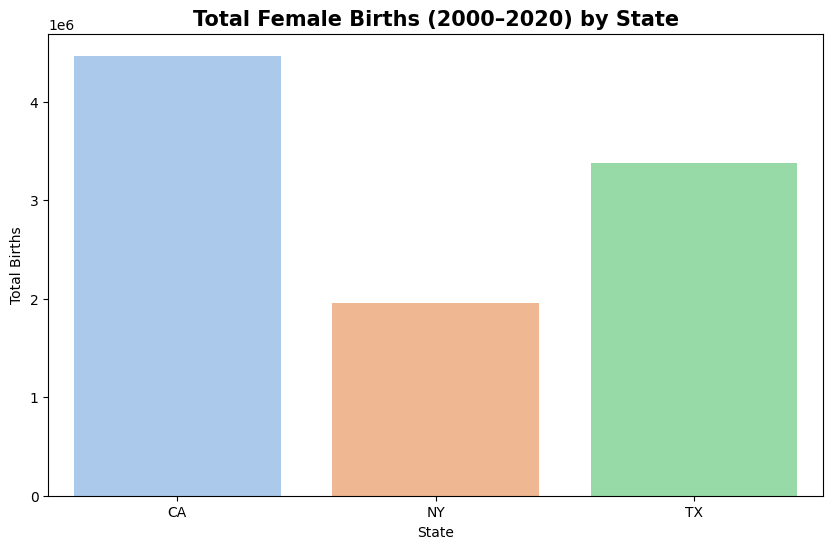

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=df_pub,
    x="state",
    y="number",
    estimator=sum,
    errorbar=None,
    hue="state",
    legend=False,
    palette="pastel"
)
plt.title("Total Female Births (2000–2020) by State", fontsize=15, fontweight="bold")
plt.xlabel("State")
plt.ylabel("Total Births")
plt.show()

***Description:***



* Sets the figure size for the plot using `plt.figure(figsize=(10,6))`.
* Creates a bar plot with Seaborn (`sns.barplot`) to show total female births by state:
  - `data=df_pub` specifies the DataFrame.
  - `x="state"` and `y="number"` set the axes.
  - `estimator=sum` aggregates the total number of births per state.
  - `errorbar=None` disables error bars.
  - `hue="state"` differentiates bars by state color.
  - `legend=False` hides the legend.
  - `palette="pastel"` sets a pastel color scheme.
* Adds a title, x-label, and y-label with formatting for readability.
* Displays the plot with `plt.show()`.
* Provides a visual summary of female birth counts from 2000–2020 across selected states.


# Data Exploration using PySpark

### Importing PySpark Modules for Data Analysis

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum as _sum, avg, max as _max, min as _min, count as _count, row_number, rank, lag, lead
from pyspark.sql.window import Window

***Description:***



* Imports `SparkSession` to create and manage a Spark application.
* Imports PySpark SQL functions:
  - `col` for column selection and manipulation.
  - Aggregation functions: `sum`, `avg`, `max`, `min`, `count` (aliased to `_sum`, `_max`, `_min`, `_count` to avoid naming conflicts).
  - Window functions: `row_number`, `rank`, `lag`, `lead`.
* Imports `Window` from `pyspark.sql.window` to define window specifications for performing advanced analytical functions.
* Prepares the environment for Spark DataFrame operations, aggregations, and window-based analytics.


### Creating SparkSession for the Diabetes Lab

In [ ]:
spark = SparkSession.builder.appName("DiabetesLab_Join_Aggregation_Window").getOrCreate()

***Description:***



* Initializes a SparkSession named `"DiabetesLab_Join_Aggregation_Window"` using `SparkSession.builder.appName()`.
* Calls `.getOrCreate()` to either retrieve an existing SparkSession or create a new one.
* Prepares the Spark environment for DataFrame operations, joins, aggregations, and window functions.


### Loading Diabetes Dataset into Spark DataFrame

In [ ]:
file_path = "/content/drive/MyDrive/diabetes_dataset.csv"
df = spark.read.csv(file_path, header=True, inferSchema=True)

***Description:***



* Specifies the file path of the diabetes CSV dataset in `file_path`.
* Reads the CSV file into a Spark DataFrame `df` using `spark.read.csv()`.
* Sets `header=True` to use the first row as column names.
* Sets `inferSchema=True` to automatically detect data types for each column.
* Prepares the dataset for further Spark DataFrame operations like joins, aggregations, and window functions.


### Inspecting the Schema of the Diabetes Dataset

In [ ]:
print(" Diabetes Dataset Loaded")
df.printSchema()

 Diabetes Dataset Loaded
root
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- ethnicity: string (nullable = true)
 |-- education_level: string (nullable = true)
 |-- income_level: string (nullable = true)
 |-- employment_status: string (nullable = true)
 |-- smoking_status: string (nullable = true)
 |-- alcohol_consumption_per_week: integer (nullable = true)
 |-- physical_activity_minutes_per_week: integer (nullable = true)
 |-- diet_score: double (nullable = true)
 |-- sleep_hours_per_day: double (nullable = true)
 |-- screen_time_hours_per_day: double (nullable = true)
 |-- family_history_diabetes: integer (nullable = true)
 |-- hypertension_history: integer (nullable = true)
 |-- cardiovascular_history: integer (nullable = true)
 |-- bmi: double (nullable = true)
 |-- waist_to_hip_ratio: double (nullable = true)
 |-- systolic_bp: integer (nullable = true)
 |-- diastolic_bp: integer (nullable = true)
 |-- heart_rate: integer (nullable = true)
 |-- chole

***Description:***



* Prints a message confirming that the diabetes dataset has been loaded.
* Uses `df.printSchema()` to display the structure of the Spark DataFrame:
  - Lists all columns.
  - Shows their data types.
  - Indicates whether null values are allowed.
* Helps verify that the dataset has been loaded correctly and that column types are inferred properly for analysis.


### Previewing the Diabetes Dataset

In [ ]:
df.show(5)

+---+------+---------+---------------+------------+-----------------+--------------+----------------------------+----------------------------------+----------+-------------------+-------------------------+-----------------------+--------------------+----------------------+----+------------------+-----------+------------+----------+-----------------+---------------+---------------+-------------+---------------+--------------------+-------------+-----+-------------------+--------------+------------------+
|age|gender|ethnicity|education_level|income_level|employment_status|smoking_status|alcohol_consumption_per_week|physical_activity_minutes_per_week|diet_score|sleep_hours_per_day|screen_time_hours_per_day|family_history_diabetes|hypertension_history|cardiovascular_history| bmi|waist_to_hip_ratio|systolic_bp|diastolic_bp|heart_rate|cholesterol_total|hdl_cholesterol|ldl_cholesterol|triglycerides|glucose_fasting|glucose_postprandial|insulin_level|hba1c|diabetes_risk_score|diabetes_stage|di

***Description:***



* Uses `df.show(5)` to display the first 5 rows of the Spark DataFrame.
* Provides a quick look at the data, including values of each column.
* Helps in understanding the dataset's structure and content before performing further analysis.


# Create sample DataFrames for JOIN operations

### Selecting Specific Columns for Analysis

In [ ]:
df_demo = df.select("age", "gender", "education_level")

***Description:***



* Creates a new DataFrame `df_demo` by selecting only the columns `age`, `gender`, and `education_level` from `df`.
* Focuses the dataset on key demographic attributes for further analysis.
* Reduces data complexity by working with only relevant columns.


### Selecting Medical Attributes for Analysis

In [ ]:
df_med = df.select("glucose_fasting", "bmi", "hba1c", "diabetes_stage")

***Description:***



* Creates a new DataFrame `df_med` by selecting columns related to medical measurements: `glucose_fasting`, `bmi`, `hba1c`, and `diabetes_stage`.
* Focuses the dataset on health-related features for further analysis, aggregation, or visualization.
* Simplifies subsequent operations by isolating relevant medical attributes from the full dataset.


### Creating a Small Spark DataFrame for Diagnosis Information

In [ ]:
from pyspark.sql import Row
df_diag = spark.createDataFrame([
    Row(patient_id=1, diagnosed_diabetes=1, year=2023),
    Row(patient_id=2, diagnosed_diabetes=0, year=2023),
    Row(patient_id=3, diagnosed_diabetes=1, year=2023),
    Row(patient_id=4, diagnosed_diabetes=1, year=2023),
    Row(patient_id=5, diagnosed_diabetes=0, year=2023)
])

***Description:***



* Imports `Row` from `pyspark.sql`.
* Creates a small Spark DataFrame `df_diag` manually with patient diagnosis information.
* Columns include:
  - `patient_id`: Unique identifier for each patient.
  - `diagnosed_diabetes`: Indicates if the patient has been diagnosed (1 = Yes, 0 = No).
  - `year`: The year of diagnosis.
* Provides a simple dataset for demonstration of joins, aggregations, or other Spark operations.


### Creating a Spark DataFrame with Demographic Information and Patient IDs

In [ ]:
from pyspark.sql import Row
df_demo_with_id = spark.createDataFrame([
    Row(patient_id=1, age=58, gender='Male', education_level='Highschool'),
    Row(patient_id=2, age=48, gender='Female', education_level='Highschool'),
    Row(patient_id=3, age=60, gender='Male', education_level='Highschool'),
    Row(patient_id=4, age=74, gender='Female', education_level='Highschool'),
    Row(patient_id=5, age=46, gender='Male', education_level='Graduate')
])

***Description:***



* Imports `Row` from `pyspark.sql`.
* Creates a Spark DataFrame `df_demo_with_id` manually with patient demographic data.
* Columns include:
  - `patient_id`: Unique identifier for each patient.
  - `age`: Age of the patient.
  - `gender`: Gender of the patient.
  - `education_level`: Highest education level attained by the patient.
* Provides a small dataset suitable for demonstrating joins, aggregations, or other operations on demographic data.


### Demonstrating Different Types of Spark DataFrame Joins


In [ ]:
print("\nInner Join:")
inner_join = df_demo_with_id.join(df_diag, on="patient_id", how="inner")
inner_join.show()

print("\nLeft Join:")
left_join  = df_demo_with_id.join(df_diag, on="patient_id", how="left")
left_join.show()

print("\nRight Join:")
right_join = df_demo_with_id.join(df_diag, on="patient_id", how="right")
right_join.show()

print("\nFull Outer Join:")
full_join  = df_demo_with_id.join(df_diag, on="patient_id", how="outer")
full_join.show()


Inner Join:
+----------+---+------+---------------+------------------+----+
|patient_id|age|gender|education_level|diagnosed_diabetes|year|
+----------+---+------+---------------+------------------+----+
|         1| 58|  Male|     Highschool|                 1|2023|
|         2| 48|Female|     Highschool|                 0|2023|
|         3| 60|  Male|     Highschool|                 1|2023|
|         4| 74|Female|     Highschool|                 1|2023|
|         5| 46|  Male|       Graduate|                 0|2023|
+----------+---+------+---------------+------------------+----+


Left Join:
+----------+---+------+---------------+------------------+----+
|patient_id|age|gender|education_level|diagnosed_diabetes|year|
+----------+---+------+---------------+------------------+----+
|         1| 58|  Male|     Highschool|                 1|2023|
|         2| 48|Female|     Highschool|                 0|2023|
|         5| 46|  Male|       Graduate|                 0|2023|
|         3| 6

***Description:***


* Performs various joins between `df_demo_with_id` and `df_diag` on the `patient_id` column:

  1. **Inner Join** (`how="inner"`):  
     - Returns only the rows where `patient_id` exists in both DataFrames.
     - Stores the result in `inner_join` and displays it using `.show()`.

  2. **Left Join** (`how="left"`):  
     - Returns all rows from the left DataFrame (`df_demo_with_id`) and matching rows from the right DataFrame (`df_diag`).
     - Stores the result in `left_join` and displays it.

  3. **Right Join** (`how="right"`):  
     - Returns all rows from the right DataFrame (`df_diag`) and matching rows from the left DataFrame (`df_demo_with_id`).
     - Stores the result in `right_join` and displays it.

  4. **Full Outer Join** (`how="outer"`):  
     - Returns all rows from both DataFrames, with `null` for missing matches.
     - Stores the result in `full_join` and displays it.

* Demonstrates how different join types affect the merged DataFrame based on key column matches.


# Aggregation operations

### Performing Aggregations by Diabetes Stage

In [ ]:
agg_results = df.groupBy("diabetes_stage").agg(
    _count("*").alias("count_records"),
    _sum("glucose_fasting").alias("total_glucose"),
    avg("bmi").alias("avg_bmi"),
    _max("hba1c").alias("max_hba1c"),
    _min("hba1c").alias("min_hba1c")
)
print("\n Aggregation by diabetes_stage:")
agg_results.show()


 Aggregation by diabetes_stage:
+--------------+-------------+-------------+------------------+---------+---------+
|diabetes_stage|count_records|total_glucose|           avg_bmi|max_hba1c|min_hba1c|
+--------------+-------------+-------------+------------------+---------+---------+
|   No Diabetes|         7981|       718738|24.639807041724094|     5.69|      4.0|
|  Pre-Diabetes|        31845|      3368213|25.327457999685972|     6.49|      4.0|
|   Gestational|          278|        30182|25.002158273381298|     8.91|     4.18|
|        Type 1|          122|        13015| 24.70901639344263|     8.54|     4.46|
|        Type 2|        59774|      6981564| 25.89917020778267|      9.8|      4.0|
+--------------+-------------+-------------+------------------+---------+---------+



***Description:***



* Groups the Spark DataFrame `df` by `diabetes_stage` using `.groupBy()`.
* Performs multiple aggregation operations with `.agg()`:
  - `_count("*").alias("count_records")`: Counts the total records per stage.
  - `_sum("glucose_fasting").alias("total_glucose")`: Calculates the total fasting glucose per stage.
  - `avg("bmi").alias("avg_bmi")`: Computes the average BMI per stage.
  - `_max("hba1c").alias("max_hba1c")`: Finds the maximum HbA1c per stage.
  - `_min("hba1c").alias("min_hba1c")`: Finds the minimum HbA1c per stage.
* Stores the results in `agg_results` and displays them using `.show()`.
* Demonstrates how to summarize key health metrics for each diabetes stage efficiently.


# Window Functions

### Applying Window Functions on Spark DataFrame

In [ ]:
windowSpec = Window.partitionBy("diabetes_stage").orderBy(col("glucose_fasting").desc())

df_window = df.withColumn("rank", rank().over(windowSpec)) \
              .withColumn("row_number", row_number().over(windowSpec)) \
              .withColumn("prev_glucose", lag("glucose_fasting", 1).over(windowSpec)) \
              .withColumn("next_glucose", lead("glucose_fasting", 1).over(windowSpec))

print("\n Window Function Results:")
df_window.select("diabetes_stage", "glucose_fasting", "rank", "row_number", "prev_glucose", "next_glucose").show(10)


 Window Function Results:
+--------------+---------------+----+----------+------------+------------+
|diabetes_stage|glucose_fasting|rank|row_number|prev_glucose|next_glucose|
+--------------+---------------+----+----------+------------+------------+
|   Gestational|            138|   1|         1|        NULL|         137|
|   Gestational|            137|   2|         2|         138|         137|
|   Gestational|            137|   2|         3|         137|         137|
|   Gestational|            137|   2|         4|         137|         136|
|   Gestational|            136|   5|         5|         137|         136|
|   Gestational|            136|   5|         6|         136|         134|
|   Gestational|            134|   7|         7|         136|         134|
|   Gestational|            134|   7|         8|         134|         133|
|   Gestational|            133|   9|         9|         134|         133|
|   Gestational|            133|   9|        10|         133|         132

***Description:***



* Defines a window specification `windowSpec` that:
  - Partitions data by `diabetes_stage`.
  - Orders rows within each partition by `glucose_fasting` in descending order.

* Adds multiple columns using window functions:
  - `rank`: Rank of each row within its diabetes stage partition.
  - `row_number`: Sequential row number within the partition.
  - `prev_glucose`: Previous row's `glucose_fasting` value using `lag`.
  - `next_glucose`: Next row's `glucose_fasting` value using `lead`.

* Stores the transformed DataFrame in `df_window`.
* Selects relevant columns and displays the first 10 rows using `.show(10)`.
* Demonstrates advanced analytics using Spark window functions to analyze relative positions and trends within each diabetes stage.


### Converting Spark DataFrame to Pandas for Visualization

In [ ]:
df_pd = df_window.toPandas()
print("\n Converted to Pandas DataFrame for Visualization.")


 Converted to Pandas DataFrame for Visualization.


***Description:***



* Converts the Spark DataFrame `df_window` into a Pandas DataFrame `df_pd` using `.toPandas()`.
* Prints a message confirming the conversion.
* Allows using Pandas and visualization libraries like Matplotlib or Seaborn for further analysis and plotting.


# Data Visualization and Insights

###Bar Plot –  Visualizing Average BMI by Diabetes Stage

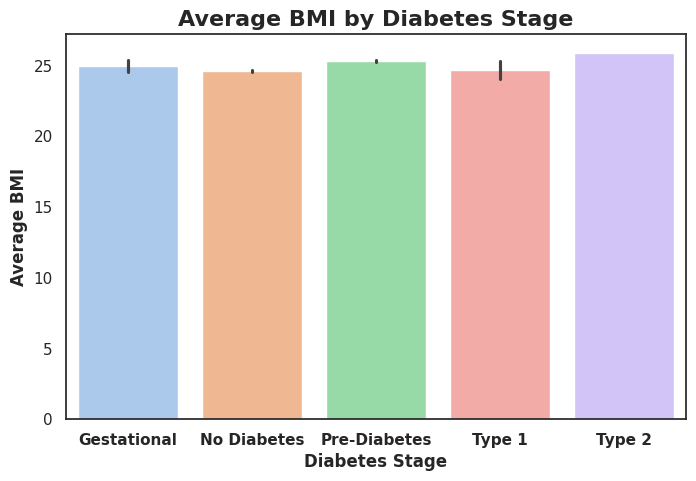

In [ ]:
sns.set(style="white")
plt.figure(figsize=(8,5))
sns.barplot(
    data=df_pd,
    x="diabetes_stage",
    y="bmi",
    estimator=np.mean,
    hue="diabetes_stage",
    legend=False,
    palette="pastel"
)
plt.title("Average BMI by Diabetes Stage", fontsize=16, fontweight='bold')
plt.xlabel("Diabetes Stage", fontsize=12, fontweight='bold')
plt.ylabel("Average BMI", fontsize=12, fontweight='bold')
plt.xticks(rotation=0, fontweight='bold')
plt.grid(False)
plt.show()


***Description:***



* Sets Seaborn style to `"white"` for a clean look.
* Creates a figure of size 8x5 inches using `plt.figure()`.
* Plots a bar chart with Seaborn (`sns.barplot`):
  - `data=df_pd` specifies the Pandas DataFrame.
  - `x="diabetes_stage"` and `y="bmi"` set the axes.
  - `estimator=np.mean` calculates the mean BMI for each diabetes stage.
  - `hue="diabetes_stage"` differentiates bars by stage color.
  - `legend=False` hides the legend.
  - `palette="pastel"` sets a pastel color scheme.
* Adds title and axis labels with bold font and appropriate sizes.
* Rotates x-axis labels and disables the grid for better readability.
* Displays the plot with `plt.show()`.
* Provides a visual summary of average BMI across different diabetes stages.


###Line Plot –  Visualizing Fasting Glucose vs Age

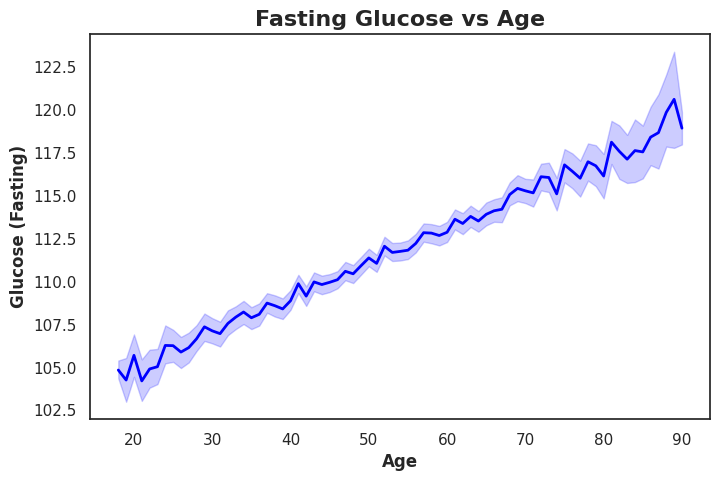

In [ ]:
plt.figure(figsize=(8,5))
sns.lineplot(data=df_pd, x="age", y="glucose_fasting", color='blue', linewidth=2)
plt.title("Fasting Glucose vs Age", fontsize=16, fontweight='bold')
plt.xlabel("Age", fontsize=12, fontweight='bold')
plt.ylabel("Glucose (Fasting)", fontsize=12, fontweight='bold')
plt.grid(False)
plt.show()

***Description:***



* Creates a figure of size 8x5 inches using `plt.figure()`.
* Plots a line chart with Seaborn (`sns.lineplot`):
  - `data=df_pd` specifies the Pandas DataFrame.
  - `x="age"` and `y="glucose_fasting"` set the axes.
  - `color='blue'` and `linewidth=2` customize the line appearance.
* Adds title and axis labels with bold font and appropriate sizes.
* Disables the grid for a clean visual presentation.
* Displays the plot with `plt.show()`.
* Shows the trend of fasting glucose levels across different ages in the dataset.


### Heatmap –Visualizing Feature Correlations with a Heatmap

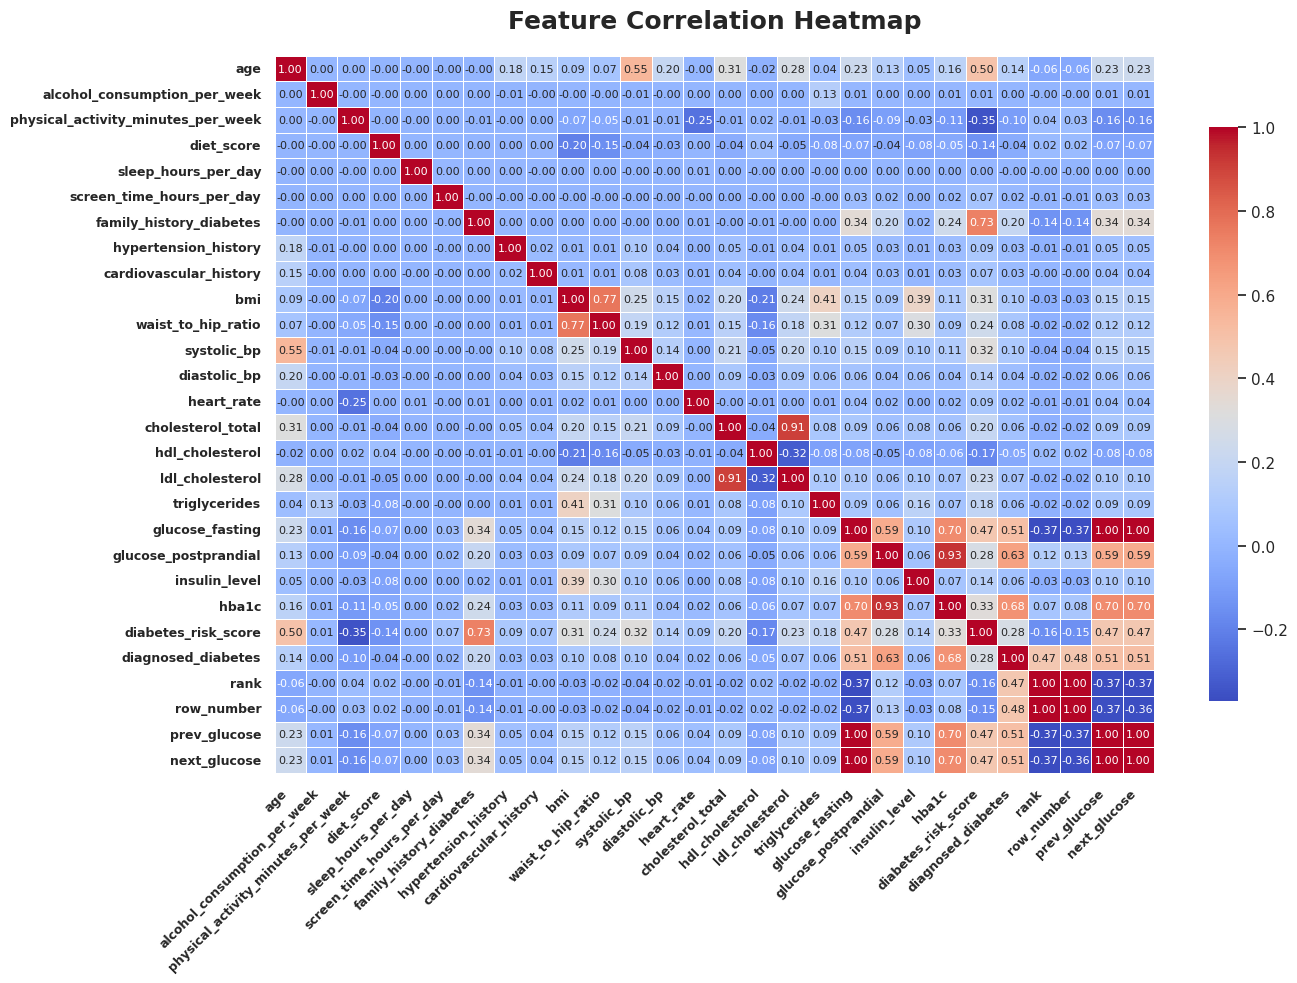

In [ ]:
corr = df_pd.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8}
)

plt.title("Feature Correlation Heatmap", fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9, fontweight='bold')
plt.yticks(fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


***Description:***



* Calculates the correlation matrix `corr` for all numerical columns in `df_pd` using `.corr()`.
* Creates a figure of size 14x10 inches.
* Plots a heatmap with Seaborn (`sns.heatmap`):
  - `annot=True` displays correlation values on the heatmap.
  - `cmap="coolwarm"` sets the color scheme.
  - `fmt=".2f"` formats numbers to 2 decimal places.
  - `linewidths=0.5` adds lines between cells for clarity.
  - `annot_kws={"size": 8}` adjusts annotation font size.
  - `cbar_kws={"shrink": 0.8}` shrinks the color bar for better fit.
* Adds a title with bold font and padding, and customizes x and y ticks for readability.
* Uses `plt.tight_layout()` to adjust spacing and `plt.show()` to display the plot.
* Provides a visual summary of relationships between numerical features in the dataset.


### Key Insights from the Analysis

In [ ]:
print("\nInsights:")
print("- Higher diabetes stages often show **higher average glucose and BMI** levels.")
print("- **Glucose increases with age**, indicating a growing risk factor over time.")
print("- Strong **positive correlation** between glucose_fasting and hba1c, confirming diagnostic consistency.")


Insights:
- Higher diabetes stages often show **higher average glucose and BMI** levels.
- **Glucose increases with age**, indicating a growing risk factor over time.
- Strong **positive correlation** between glucose_fasting and hba1c, confirming diagnostic consistency.


***Description:***



* Higher diabetes stages generally exhibit **higher average glucose and BMI** levels.
* **Glucose levels tend to increase with age**, indicating a growing risk factor over time.
* There is a strong **positive correlation** between `glucose_fasting` and `hba1c`, confirming diagnostic consistency.
* Summarizes major observations derived from visualizations and statistical analysis of the dataset.


### Installing Libraries and Importing Modules for ML Pipeline

In [ ]:
!pip install requests beautifulsoup4 pyspark scikit-learn xgboost imbalanced-learn

import requests
from bs4 import BeautifulSoup
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.decomposition import PCA
from sklearn.feature_selection import RFE
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

***Description:***



* Installs essential Python libraries:  
  - `requests`, `beautifulsoup4` → Web scraping and HTML parsing.  
  - `pyspark` → Big Data processing with Spark DataFrames and RDDs.  
  - `scikit-learn` → Machine learning preprocessing, modeling, evaluation, and feature selection.  
  - `xgboost` → Gradient boosting ML model.  
  - `imbalanced-learn` → Handling class imbalance with SMOTE.

* Imports PySpark modules:
  - `SparkSession` → To create and manage Spark sessions.
  - `functions.col` → For column operations in Spark DataFrames.

* Imports scikit-learn modules:
  - `MinMaxScaler`, `StandardScaler` → Scaling numerical features.
  - `train_test_split`, `GridSearchCV` → Data splitting and hyperparameter tuning.
  - `RandomForestClassifier` → Tree-based ML model.
  - `PCA` → Dimensionality reduction.
  - Evaluation metrics → `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `roc_auc_score`.

* Imports `warnings` and suppresses warning messages.

* Prepares the environment for building, evaluating, and tuning machine learning models.


# Acquire Real Health Data from a Public **API**

### Fetching and Saving WHO-like Public Health Data (COVID-19 Example)

In [ ]:
# WHO-like health data (COVID-19 stats as an example of public health data)
api_url = "https://disease.sh/v3/covid-19/countries/pakistan"
response = requests.get(api_url)
data_api = response.json()
# Save API data to JSON
import json
with open("health_api_data.json", "w") as f:
    json.dump(data_api, f, indent=4)
print(" Health API Data Saved Successfully!")
print("Country:", data_api["country"])
print("Total Cases:", data_api["cases"])
print("Recovered:", data_api["recovered"])
print("Deaths:", data_api["deaths"])

 Health API Data Saved Successfully!
Country: Pakistan
Total Cases: 1581936
Recovered: 1538689
Deaths: 30664


***Description:***



* Uses the `requests` library to fetch COVID-19 statistics from a public API:
  - `api_url` points to country-specific data (Pakistan in this case).
  - `response.json()` converts the API response to a Python dictionary.

* Saves the fetched data as a JSON file:
  - Uses `json.dump()` with indentation for readability.
  - File saved as `"health_api_data.json"`.

* Prints key information from the dataset:
  - Country name
  - Total COVID-19 cases
  - Recovered cases
  - Deaths

* Demonstrates how to retrieve, store, and inspect public health data programmatically for analysis or reporting.


# Web Scraping

### Web Scraping WHO Health Fact Sheets

In [ ]:
url = "https://www.who.int/news-room/fact-sheets"
html = requests.get(url).text
soup = BeautifulSoup(html, "html.parser")

facts = []
for item in soup.find_all("a", class_="link-container"):
    title = item.get_text(strip=True)
    if title:
        facts.append(title)

df_facts = pd.DataFrame(facts, columns=["Health Facts"])
df_facts.to_csv("web_scraped_health_facts.csv", index=False)
print(" Web Scraped Health Facts Saved to CSV")
df_facts.head()

 Web Scraped Health Facts Saved to CSV


,Health Facts


***Description:***



* Fetches HTML content from WHO's news-room fact sheets page using `requests`.
* Parses the HTML with `BeautifulSoup`.
* Extracts titles of all fact sheets:
  - Searches for `<a>` tags with class `"link-container"`.
  - Strips and stores non-empty titles in a Python list `facts`.
* Converts the list of health facts into a Pandas DataFrame `df_facts`.
* Saves the DataFrame to CSV file `"web_scraped_health_facts.csv"` for further analysis.
* Displays the first few rows of the scraped data using `.head()`.
* Demonstrates programmatic extraction of public health information from web pages.


### Loading Health Dataset (Diabetes Example)




In [ ]:
#Load Your Health Dataset
file_path = "/content/drive/MyDrive/diabetes_dataset.csv"
df = pd.read_csv(file_path)
print(" Health Dataset Loaded Successfully!")
print(df.head())

 Health Dataset Loaded Successfully!
   age  gender ethnicity education_level  income_level employment_status  \
0   58    Male     Asian      Highschool  Lower-Middle          Employed   
1   48  Female     White      Highschool        Middle          Employed   
2   60    Male  Hispanic      Highschool        Middle        Unemployed   
3   74  Female     Black      Highschool           Low           Retired   
4   46    Male     White        Graduate        Middle           Retired   

  smoking_status  alcohol_consumption_per_week  \
0          Never                             0   
1         Former                             1   
2          Never                             1   
3          Never                             0   
4          Never                             1   

   physical_activity_minutes_per_week  diet_score  ...  hdl_cholesterol  \
0                                 215         5.7  ...               41   
1                                 143         6.7  ... 

***Description:***

* Loads a local CSV dataset containing health-related data (e.g., diabetes indicators) using `pandas.read_csv()`.
* Stores the data in a Pandas DataFrame `df`.
* Prints a success message after loading the dataset.
* Displays the first few rows of the dataset using `.head()` to inspect the data structure.
* Prepares the dataset for further analysis, cleaning, and visualization.

# Integrate with PySpark

### Using PySpark for Health Data Analysis

In [ ]:
spark = SparkSession.builder.appName("HealthDataSpark").getOrCreate()
df_spark = spark.createDataFrame(df_pd)
# Example Transformation: average glucose_fasting level by diabetes outcome
result = df_spark.groupBy("diagnosed_diabetes").avg("glucose_fasting")
print(" Average Fasting Glucose Level by Diagnosed Diabetes:")
result.show()

 Average Fasting Glucose Level by Diagnosed Diabetes:
+------------------+--------------------+
|diagnosed_diabetes|avg(glucose_fasting)|
+------------------+--------------------+
|                 0|   102.6101194940253|
|                 1|  116.78892629754326|
+------------------+--------------------+



***Description:***



* Creates a Spark session using `SparkSession.builder`.
* Converts the Pandas DataFrame `df_pd` to a Spark DataFrame `df_spark`.
* Performs a simple aggregation:
  - Groups data by `"diagnosed_diabetes"` column.
  - Calculates the average `"glucose_fasting"` for each group using `.groupBy().avg()`.
* Prints a descriptive message and displays the results using `.show()`.
* Demonstrates how PySpark can be used to efficiently process and analyze health datasets.


# Data Preprocessing

### Handling Missing Values and Encoding Categorical Data

In [ ]:
from sklearn.preprocessing import LabelEncoder
# Separate numeric and categorical columns
num_cols = df_pd.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df_pd.select_dtypes(include=['object']).columns
# 1️ Fill missing values
df_pd[num_cols] = df_pd[num_cols].fillna(df_pd[num_cols].mean())
df_pd[cat_cols] = df_pd[cat_cols].fillna(df_pd[cat_cols].mode().iloc[0])  # mode for categorical
# 2️ Encode categorical variables
le = LabelEncoder()
for col in cat_cols:
    df_pd[col] = le.fit_transform(df_pd[col])

print(" Missing values handled and categorical columns encoded!")
print(df_pd.head())

 Missing values handled and categorical columns encoded!
   age  gender  ethnicity  education_level  income_level  employment_status  \
0   28       0          1                1             2                  0   
1   42       0          1                0             3                  0   
2   41       0          2                0             2                  3   
3   41       0          4                1             2                  1   
4   29       0          4                0             3                  1   

   smoking_status  alcohol_consumption_per_week  \
0               2                             4   
1               0                             4   
2               2                             3   
3               2                             2   
4               2                             4   

   physical_activity_minutes_per_week  diet_score  ...  glucose_postprandial  \
0                                  46         5.1  ...                   217   
1

***Description:***



* Imports `LabelEncoder` from scikit-learn for encoding categorical features.
* Separates numeric and categorical columns:
  - `num_cols` → Columns with numeric data (`int64`, `float64`).
  - `cat_cols` → Columns with categorical data (`object`).
* Handles missing values:
  - Numeric columns → Fill missing values with column mean.
  - Categorical columns → Fill missing values with mode (most frequent value).
* Encodes categorical columns:
  - Uses `LabelEncoder` to convert text labels into numeric values for ML compatibility.
* Prints confirmation message and displays the first few rows using `.head()`.
* Prepares the dataset for modeling by ensuring no missing values and all categorical features are numeric.


### Splitting Features & Target and Scaling Data

In [ ]:
#  Split data
X = df_pd.drop("diagnosed_diabetes", axis=1)   # use correct target column name
y = df_pd["diagnosed_diabetes"]
# 4️ Scaling
minmax = MinMaxScaler()
standard = StandardScaler()
X_minmax = minmax.fit_transform(X)
X_std = standard.fit_transform(X)

print(" Preprocessing completed successfully!")

 Preprocessing completed successfully!


***Description:***



* Splits the dataset into features (`X`) and target (`y`):
  - `X` → All columns except the target column `"diagnosed_diabetes"`.
  - `y` → Target column `"diagnosed_diabetes"`.

* Scales the feature data for machine learning:
  - `MinMaxScaler` → Scales features to a range [0,1].
  - `StandardScaler` → Standardizes features to zero mean and unit variance.
  - Produces `X_minmax` and `X_std` as scaled versions of `X`.

* Prints a confirmation message once preprocessing is complete.
* Ensures data is ready for training ML models with scaled features.


# Feature Selection (RFE + PCA)

### Feature Selection and Dimensionality Reduction

In [ ]:
#  Recursive Feature Elimination (RFE)
rfe_model = RandomForestClassifier()
rfe = RFE(rfe_model, n_features_to_select=10)
rfe.fit(X_std, y)
selected_features = X.columns[rfe.support_]
print(" Top 10 Selected Features (RFE):", list(selected_features))
#  Principal Component Analysis (PCA)
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_std)
print(" PCA Explained Variance Ratio:", pca.explained_variance_ratio_)

 Top 10 Selected Features (RFE): ['physical_activity_minutes_per_week', 'glucose_fasting', 'glucose_postprandial', 'hba1c', 'diabetes_risk_score', 'diabetes_stage', 'rank', 'row_number', 'prev_glucose', 'next_glucose']
 PCA Explained Variance Ratio: [0.16379082 0.08095136 0.07794956 0.05297783 0.04134318]


***Description:***



* **Recursive Feature Elimination (RFE)**:
  - Initializes a `RandomForestClassifier` as the base model.
  - Selects the top 10 most important features using RFE on standardized data (`X_std`).
  - Prints the selected feature names to identify the most influential predictors for the target.

* **Principal Component Analysis (PCA)**:
  - Reduces feature dimensionality to 5 principal components.
  - Transforms the standardized data (`X_std`) into `X_pca`.
  - Prints the explained variance ratio of each principal component to understand data variance coverage.

* Prepares the dataset for modeling with both selected features and reduced dimensions, improving model efficiency and interpretability.


### Handling Class Imbalance with SMOTE

In [ ]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_std, y)
print(" Class Balance After SMOTE:")
print(y_res.value_counts())

 Class Balance After SMOTE:
diagnosed_diabetes
1    59998
0    59998
Name: count, dtype: int64


***Description:***



* Initializes SMOTE (`Synthetic Minority Oversampling Technique`) with `random_state=42`.
* Applies SMOTE to the standardized feature set (`X_std`) and target (`y`) to generate a balanced dataset:
  - `X_res` → Resampled features.
  - `y_res` → Resampled target with balanced classes.
* Prints the class distribution after SMOTE to verify balancing.
* Ensures that machine learning models are trained on balanced data, reducing bias toward the majority class.


### Splitting Resampled Data into Training and Testing Sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

***Description:***



* Uses `train_test_split` from scikit-learn to divide the balanced dataset into training and testing sets.
  - `X_train`, `y_train` → 80% of the data used for training models.
  - `X_test`, `y_test` → 20% of the data reserved for model evaluation.
* Sets `random_state=42` for reproducibility of results.
* Prepares the dataset for supervised machine learning by ensuring separate training and testing subsets.



### Training Machine Learning Models( with Hyperparameter Tuning)

In [ ]:
# Random Forest with Grid Search
rf = RandomForestClassifier()
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [3, 5, None]
}
grid = GridSearchCV(rf, param_grid, cv=3, scoring="f1")
grid.fit(X_train, y_train)
best_rf = grid.best_estimator_
# Support Vector Machine
svm = SVC(probability=True)
svm.fit(X_train, y_train)
# XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric="logloss")
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

***Description:***



* **Random Forest with Grid Search**:
  - Initializes a `RandomForestClassifier`.
  - Defines a parameter grid for `n_estimators` and `max_depth`.
  - Uses `GridSearchCV` with 3-fold cross-validation to find the best hyperparameters based on F1 score.
  - Fits the model on the training data (`X_train`, `y_train`).
  - Stores the best estimator as `best_rf`.

* **Support Vector Machine (SVM)**:
  - Initializes `SVC` with `probability=True` to enable probability predictions.
  - Fits the SVM model on the training data.

* **XGBoost Classifier**:
  - Initializes `XGBClassifier` with `use_label_encoder=False` and `eval_metric="logloss"`.
  - Fits the XGBoost model on the training data.

* Prepares three different machine learning models for evaluation and comparison on the balanced dataset.


# Model Evaluation

### Evaluating and Comparing ML Model Performance

In [ ]:
models = {
    "Random Forest": best_rf,
    "SVM": svm,
    "XGBoost": xgb
}
results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    })
df_results = pd.DataFrame(results)
print(" Model Performance Comparison:")
print(df_results)

 Model Performance Comparison:
           Model  Accuracy  Precision    Recall  F1 Score       AUC
0  Random Forest  0.999708   1.000000  0.999415  0.999707  0.999989
1            SVM  0.998708   1.000000  0.997409  0.998703  0.999842
2        XGBoost  0.999708   0.999916  0.999498  0.999707  0.999999


***Description:***



* Defines a dictionary `models` containing the trained machine learning models:
  - Random Forest (`best_rf`)
  - Support Vector Machine (`svm`)
  - XGBoost (`xgb`)

* Iterates through each model to:
  - Predict the target values for the test set (`X_test`).
  - Calculate performance metrics:
    - Accuracy
    - Precision
    - Recall
    - F1 Score
    - AUC (Area Under ROC Curve)

* Stores the results in a list of dictionaries and converts it into a Pandas DataFrame `df_results`.

* Prints the performance comparison of all models, enabling selection of the best-performing classifier.


### Selecting the Best Performing Model

In [ ]:
#Best Model Selection
best_model = df_results.loc[df_results["F1 Score"].idxmax()]
print("\n Best Performing Health Model:")
print(best_model)


 Best Performing Health Model:
Model         XGBoost
Accuracy     0.999708
Precision    0.999916
Recall       0.999498
F1 Score     0.999707
AUC          0.999999
Name: 2, dtype: object


***Description:***



* Identifies the best model based on the highest F1 Score from `df_results`.
* Uses `.idxmax()` to locate the row with the maximum F1 Score.
* Stores the best-performing model's metrics in `best_model`.
* Prints the selected model's performance metrics for reference.
* Helps in choosing the most effective classifier for predicting health outcomes.


### Visualizing Health Model Performance


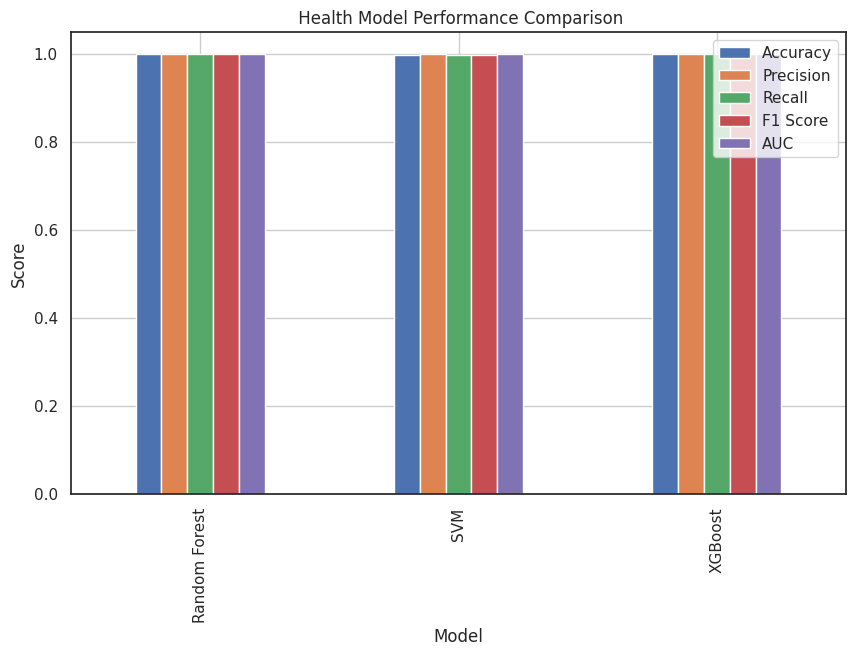

In [ ]:
import matplotlib.pyplot as plt

df_results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score", "AUC"]].plot(kind="bar", figsize=(10,6))
plt.title(" Health Model Performance Comparison")
plt.ylabel("Score")
plt.grid(True)
plt.show()

***Description:***


* Uses `matplotlib.pyplot` to create a bar chart comparing model performance metrics.
* Sets `"Model"` as the index and plots the following metrics:
  - Accuracy
  - Precision
  - Recall
  - F1 Score
  - AUC
* Configures plot size, title, y-axis label, and grid for readability.
* Helps visually compare how each machine learning model performs across multiple evaluation metrics.
